# 05- Mixed Effects Models


Multilevel/hierarchical models accounting for repeated measures within participants.

In [1]:
source("00_setup.R")

# install.packages(c("lme4", "lmerTest"), repos = "https://cloud.r-project.org")
# On macOS 26 a Fortran dependency of lme4 (minqa) fails to build unless the
# deployment target is pinned:
#   MACOSX_DEPLOYMENT_TARGET=15.0 R -e 'install.packages("lme4")'
library(lme4)
library(lmerTest)  # Provides p-values for lmer


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘jsonlite’ was built under R version 4.3.3”

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten


Loading pre-processed data...

Loaded: 24 participants, 192 observations, 96 chat observations


=== Data Loaded ===

Participants: 24

Total observations (data_long): 192

Chat observations (data_chat_analysis): 96

Loading required pa

## Data Preparation

In [2]:
# =============================================================================
# Data preparation - built ONCE here and used by every model below.
# -----------------------------------------------------------------------------
# Control selection follows the design DAG (07_dags.R) and the good/bad-control
# taxonomy of Cinelli, Forney & Pearl (2022), "A Crash Course in Good and Bad
# Controls".
#
# Condition, LLM provider, AI stance and discussed-vs-undiscussed are all
# randomised or blocked by design, so they have no parents in the DAG and no
# backdoor path needs to be closed.  No covariate is therefore a "good control"
# in Pearl's sense.  Every candidate is either NEUTRAL (include only to shrink
# the residual variance) or BAD (including it introduces bias where there was
# none).
#
#   INCLUDED  dilemma features           cause of Y only    -> neutral, precision
#             AI stance (is_opposing)    cause of Y only    -> neutral, precision
#             LLM provider (is_claude)   cause of Y only    -> neutral, precision
#             baseline extremity         cause of Y only    -> neutral, precision
#
#   EXCLUDED  llm_framework / is_utilitarian   COLLIDER on stance and rating_pre
#             chat_turns, AI message content   MEDIATORS of condition -> movement
#             debrief_stias_average            DESCENDANT of the outcome
#             debrief_noticed_persuasion       DESCENDANT of the outcome
#             debrief_changed_mind             DESCENDANT of the outcome
#
# Extremity is the sole exception: participants brought it with them rather than
# receiving it, so it is the one exposure that needs a real confounder strategy
# (handled below by the within/between split).
# =============================================================================

participant_vars <- data %>%
  dplyr::select(participant_id, condition,
                demographics_gender, demographics_age, demographics_education,
                tipi_extraversion, tipi_agreeableness, tipi_conscientiousness,
                tipi_emotional_stability, tipi_openness) %>%
  distinct(participant_id, .keep_all = TRUE)

# Nested sequential contrasts on the four arms.  H1, H2 and H3 are nested
# comparisons on the SAME four arms, so one model fitted to all 24 participants
# answers all three.  Fitting them on subsets (as the H1-H3 cells previously
# did) discarded 10 of 24 participants for H3 and bought no identification.
# The three contrasts are mutually orthogonal.
cond_contrasts <- cbind(
  C1_persuasion = c(-3/4,  1/4,  1/4, 1/4),   # H1  control        vs any persuasion
  C2_personal   = c(   0, -2/3,  1/3, 1/3),   # H2  persuade       vs personalised
  C3_info       = c(   0,    0, -1/2, 1/2)    # H3  + demographics vs + personality
)

# ---- All 192 ratings (H5 needs the undiscussed dilemmas too) -----------------
long_data <- data_long %>%
  dplyr::select(-any_of(setdiff(names(participant_vars), "participant_id"))) %>%
  left_join(participant_vars, by = "participant_id") %>%
  mutate(
    # DV: signed movement toward the AI's position
    movement_toward_ai = case_when(
      outcome == "Moved toward AI" ~ abs(rating_change),
      outcome == "Backfired"       ~ -abs(rating_change),
      TRUE                         ~ 0
    ),
    abs_change          = abs(rating_change),
    extremity           = abs(rating_pre - 4),
    rating_pre_centered = rating_pre - 4,

    is_opposing = ifelse(stance_mode == "opposite", 1, 0),
    is_claude   = ifelse(llm_provider == "anthropic", 1, 0),
    is_female   = ifelse(demographics_gender == "female", 1, 0),
    # NOTE: the education cell previously used `edu == c("high_school",
    # "some_college")`, which recycles the vector element-by-element instead of
    # testing membership and mislabels roughly half the rows.  Use %in%.
    education_group = factor(case_when(
      demographics_education %in% c("high_school", "some_college")  ~ "High School",
      demographics_education %in% c("bachelor", "master", "doctorate") ~ "Higher Education",
      TRUE ~ NA_character_
    ), levels = c("High School", "Higher Education")),
    age_c       = as.numeric(scale(demographics_age, scale = FALSE)),

    extraversion_c        = as.numeric(scale(tipi_extraversion,        scale = FALSE)),
    agreeableness_c       = as.numeric(scale(tipi_agreeableness,       scale = FALSE)),
    conscientiousness_c   = as.numeric(scale(tipi_conscientiousness,   scale = FALSE)),
    emotional_stability_c = as.numeric(scale(tipi_emotional_stability, scale = FALSE)),
    openness_c            = as.numeric(scale(tipi_openness,            scale = FALSE)),

    # Dilemma features are encoded in the dilemma code, not stored as columns:
    #   Greene   G_{P|I}{A|O}_Name        Koerner   K_{bg|bs}{A|O}_Name
    # The regex is anchored on the second token so that names containing an "A"
    # or an "O" (Data_Breach, Submarine_Oxygen, Abduction) cannot match by
    # accident, which an unanchored grepl("A_", dilemma) can.
    dil_tag        = str_match(dilemma, "^[GK]_([A-Za-z]+)_")[, 2],
    dilemma_author = ifelse(str_starts(dilemma, "G_"), "Greene", "Koerner"),
    dilemma_action = factor(ifelse(str_sub(dil_tag, -1) == "A", "Action", "Omission")),
    dilemma_type   = factor(case_when(
      dilemma_author == "Greene" & str_sub(dil_tag, 1, 1) == "P" ~ "Personal",
      dilemma_author == "Greene" & str_sub(dil_tag, 1, 1) == "I" ~ "Impersonal",
      TRUE                                                       ~ "Koerner"
    )),

    condition      = factor(condition, levels = c("neutral", "persuade",
                                                  "persuade_demo", "persuade_info")),
    participant_id = factor(participant_id),
    dilemma        = factor(dilemma)
  )
contrasts(long_data$condition) <- cond_contrasts

# ---- The 96 discussed dilemmas ----------------------------------------------
# Splitting extremity into within- and between-participant components
# identifies the within effect free of EVERY time-invariant participant
# confounder (age, gender, education, personality), measured or not - a stronger
# claim than adjusting for the handful of confounders that happen to be
# measured.  extremity_b is grand-mean centred so the stance main effect is the
# effect at average baseline extremity, not at the impossible value 0.
mixed_data <- long_data %>%
  filter(had_chat) %>%
  group_by(participant_id) %>%
  mutate(extremity_b = mean(extremity),
         extremity_w = extremity - extremity_b) %>%
  ungroup() %>%
  mutate(extremity_b    = extremity_b - mean(extremity_b),
         is_persuaded   = ifelse(outcome == "Moved toward AI", 1, 0),
         participant_id = factor(participant_id))
contrasts(mixed_data$condition) <- cond_contrasts

message(sprintf("long_data : %d ratings from %d participants",
                nrow(long_data), n_distinct(long_data$participant_id)))
message(sprintf("mixed_data: %d discussed dilemmas across %d distinct dilemmas",
                nrow(mixed_data), n_distinct(droplevels(mixed_data$dilemma))))

message("\n=== DILEMMA GROUPINGS (discussed dilemmas) ===")
print(table(mixed_data$dilemma_type, mixed_data$dilemma_action))
message("\nBy author:")
print(table(mixed_data$dilemma_author))


long_data : 192 ratings from 24 participants

mixed_data: 96 discussed dilemmas across 19 distinct dilemmas


=== DILEMMA GROUPINGS (discussed dilemmas) ===



            
             Action Omission
  Impersonal     11       13
  Koerner        24       24
  Personal       13       11



By author:




 Greene Koerner 
     48      48 


## Linear Mixed Effects Models (Continuous DV)

In [3]:
# Model 1: random intercept for participant.
# Both exposures are randomised (provider between participants, stance blocked
# within participant), so BOTH coefficients carry a causal reading - the usual
# Table 2 Fallacy warning does not bite here.
lmm_1 <- lmer(movement_toward_ai ~ is_claude + is_opposing + (1 | participant_id),
              data = mixed_data)
summary(lmm_1)


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_claude + is_opposing + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 366

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.70289 -0.52773 -0.06295  0.39820  2.73082 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.06454  0.254   
 Residual                   2.60549  1.614   
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  -0.6146     0.2867 45.5967  -2.143 0.037444 *  
is_claude     0.7500     0.3466 22.0000   2.164 0.041618 *  
is_opposing   1.2292     0.3295 71.0000   3.731 0.000381 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) is_cld
is_claude   -0.554       
is_opposing -0.575  0.000

In [4]:
# Dilemma features.  dilemma_type has 3 levels and dilemma_action has 2, so they
# belong as FIXED effects; a random intercept over 3 levels cannot be estimated
# reliably and the previous (1 | dilemma_type) term was doing nothing useful.
# Both are balanced within participant by design (each participant saw exactly
# one Greene-action, Greene-omission, Koerner-action and Koerner-omission
# dilemma), so they are neutral controls included purely for precision.

lmm_type <- lmer(movement_toward_ai ~ is_claude + is_opposing + dilemma_type +
                   (1 | participant_id), data = mixed_data)
summary(lmm_type)

lmm_action <- lmer(movement_toward_ai ~ is_claude + is_opposing + dilemma_action +
                     (1 | participant_id), data = mixed_data)
summary(lmm_action)

lmm_features <- lmer(movement_toward_ai ~ is_claude + is_opposing + dilemma_type +
                       dilemma_action + (1 | participant_id), data = mixed_data)
summary(lmm_features)

# Item-variance check.  A crossed intercept over the 19 individual dilemmas is
# the non-parametric version of the two terms above: it absorbs wording,
# framework and difficulty without spending fixed degrees of freedom.  With only
# 96 conversations it is estimated at exactly zero (singular fit), so dilemma
# identity explains no variance at this level and is omitted from the
# hypothesis models.  Report this rather than silently dropping the term.
lmm_item <- lmer(movement_toward_ai ~ is_claude + is_opposing +
                   (1 | participant_id) + (1 | dilemma), data = mixed_data)
vc_item <- as.data.frame(VarCorr(lmm_item))
message(sprintf("\nDilemma random-intercept variance: %.4f   (singular fit: %s)",
                vc_item$vcov[vc_item$grp == "dilemma"], isSingular(lmm_item)))


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_claude + is_opposing + dilemma_type +  
    (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 365.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.71211 -0.48879 -0.09174  0.38802  2.65987 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.04765  0.2183  
 Residual                   2.67303  1.6349  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                     Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)          -0.60088    0.39782 85.72496  -1.510 0.134610    
is_claude             0.75000    0.34663 22.00000   2.164 0.041618 *  
is_opposing           1.21712    0.33652 69.00000   3.617 0.000563 ***
dilemma_typeKoerner   0.05167    0.41167 69.00000   0.126 0.900483    
dilemma_typePersonal -0.13405    0.47218 69.00000  -0.284 0.777343    
--

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_claude + is_opposing + dilemma_action +  
    (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 365.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.5836 -0.5769 -0.1180  0.4629  2.6119 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.06537  0.2557  
 Residual                   2.60217  1.6131  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                       Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)             -0.4630     0.3213 62.3441  -1.441 0.154664    
is_claude                0.7500     0.3466 22.0000   2.164 0.041618 *  
is_opposing              1.2725     0.3319 70.0000   3.834 0.000272 ***
dilemma_actionOmission  -0.3466     0.3319 70.0000  -1.044 0.299971    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlat

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_claude + is_opposing + dilemma_type +  
    dilemma_action + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 365

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.59034 -0.54225 -0.05747  0.47403  2.54192 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.04855  0.2203  
 Residual                   2.66943  1.6338  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                       Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)            -0.42902    0.43028 88.65167  -0.997 0.321448    
is_claude               0.75000    0.34663 22.00017   2.164 0.041618 *  
is_opposing             1.26251    0.33908 68.00023   3.723 0.000401 ***
dilemma_typeKoerner     0.03038    0.41190 68.00023   0.074 0.941429    
dilemma_typePersonal   -0.16529    0.47280 68.00

boundary (singular) fit: see help('isSingular')


Dilemma random-intercept variance: 0.0000   (singular fit: TRUE)



In [5]:
# =============================================================================
# Covariate ladder - PRECISION ONLY, not confounding control.
# -----------------------------------------------------------------------------
# Two fixes to the previous version of this cell.
#
# 1. It rebuilt `mixed_data` from scratch, silently discarding dilemma_type and
#    dilemma_action created in the Data Preparation cell.  mixed_data is now
#    built once, above, and is not touched here.
#
# 2. Every model carried `is_claude * is_utilitarian`.  is_utilitarian is a
#    deterministic function of stance_mode and rating_pre, which makes it a
#    COLLIDER on two of the causes of the outcome.  Conditioning on it opens
#    paths instead of closing them - dagitty puts the count at 2 open backdoor
#    paths -> 12 (07_dags.R).  It is removed from every model in this notebook.
#
# Because condition, provider and stance are randomised, adding covariates
# cannot remove confounding here; it can only shrink the residual variance.
# Estimates should stay roughly stable across the ladder while standard errors
# fall.  That stability is itself the finding worth reporting: it is the
# evidence that randomisation worked.
# =============================================================================

# Model 1: Core (randomised exposures only)
lmm_core <- lmer(movement_toward_ai ~ is_claude + is_opposing +
                   (1 | participant_id), data = mixed_data)
summary(lmm_core)

# Model 2: + Condition, via the nested contrasts C1/C2/C3 = H1/H2/H3
lmm_cond <- lmer(movement_toward_ai ~ is_claude + is_opposing + condition +
                   (1 | participant_id), data = mixed_data)
summary(lmm_cond)

# Model 3: + Demographics
lmm_demo <- lmer(movement_toward_ai ~ is_claude + is_opposing + condition +
                   is_female + age_c +
                   (1 | participant_id), data = mixed_data)
summary(lmm_demo)

# Model 4: + Personality (robustness check only)
# In persuade_demo and persuade_info these traits are INPUTS to the treatment -
# they are part of what the AI was given.  Adjusting for them in the arm where
# they constitute the manipulation is conceptually incoherent, and it spends
# roughly 10 degrees of freedom out of 24 participants.  Reported for
# completeness, not as the preferred specification.
lmm_full <- lmer(movement_toward_ai ~ is_claude + is_opposing + condition +
                   is_female + age_c +
                   extraversion_c + agreeableness_c + conscientiousness_c +
                   emotional_stability_c + openness_c +
                   (1 | participant_id), data = mixed_data)
summary(lmm_full)

# NOTE ON SINGULAR FITS.  lmm_demo and lmm_full report boundary (singular) fits:
# the participant random-intercept variance goes to zero.  This is expected, not
# a failure.  Age, gender and the five TIPI scores are constant within
# participant, so as fixed effects they compete directly with the participant
# random intercept for the same between-participant variance and eventually
# absorb all of it.  With 24 participants and ~10 participant-level predictors
# there is nothing left for the random term to explain.  It is a further reason
# to prefer the lower rungs of this ladder as the reported specification.

# Model comparison with formatting
  models <- list(lmm_core, lmm_cond, lmm_demo, lmm_full)
  model_names <- c("Core", "+ Condition", "+ Demographics", "+ Personality")

  comparison <- anova(lmm_core, lmm_cond, lmm_demo, lmm_full)

  message("=== MODEL COMPARISON ===\n")

  for (i in 1:length(models)) {
    aic <- AIC(models[[i]])
    bic <- BIC(models[[i]])

    if (i == 1) {
      message(sprintf("%s: AIC=%.1f, BIC=%.1f", model_names[i], aic, bic))
    } else {
      chisq <- comparison$Chisq[i]
      p <- comparison$`Pr(>Chisq)`[i]
      sig <- ifelse(p < 0.05, "*", "")
      message(sprintf("%s: AIC=%.1f, BIC=%.1f | χ²=%.2f, p=%.3f %s",
                      model_names[i], aic, bic, chisq, p, sig))
    }
  }

  message("\n=== BEST MODEL ===")
  aics <- sapply(models, AIC)
  best_idx <- which.min(aics)
  message(sprintf("Lowest AIC: %s (%.1f)", model_names[best_idx], aics[best_idx]))



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_claude + is_opposing + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 366

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.70289 -0.52773 -0.06295  0.39820  2.73082 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.06454  0.254   
 Residual                   2.60549  1.614   
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  -0.6146     0.2867 45.5967  -2.143 0.037444 *  
is_claude     0.7500     0.3466 22.0000   2.164 0.041618 *  
is_opposing   1.2292     0.3295 71.0000   3.731 0.000381 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) is_cld
is_claude   -0.554       
is_opposing -0.575  0.000

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_claude + is_opposing + condition + (1 |  
    participant_id)
   Data: mixed_data

REML criterion at convergence: 364.1

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.69525 -0.53833 -0.07274  0.42884  2.73846 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.1344   0.3666  
 Residual                   2.6055   1.6142  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                       Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)            -0.61538    0.29679 37.69123  -2.073 0.045015 *  
is_claude               0.79348    0.36966 19.00000   2.146 0.044960 *  
is_opposing             1.22917    0.32949 71.00000   3.731 0.000381 ***
conditionC1_persuasion  0.41682    0.42332 19.00000   0.985 0.337172    
conditionC2_personal   -0.20358    0.51213 19.00000  -0.398 0.6954

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
movement_toward_ai ~ is_claude + is_opposing + condition + is_female +  
    age_c + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 369.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.73687 -0.52331 -0.06827  0.45561  2.69684 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.1983   0.4453  
 Residual                   2.6055   1.6142  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                        Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)            -0.760862   0.362081 26.600594  -2.101 0.045225 *  
is_claude               0.699920   0.406673 17.000000   1.721 0.103382    
is_opposing             1.229167   0.329487 71.000000   3.731 0.000381 ***
conditionC1_persuasion  0.335288   0.495812 17.000000   0.676 0.507984    
conditionC2_personal   -0.113736   

boundary (singular) fit: see help('isSingular')


Correlation matrix not shown by default, as p = 13 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
movement_toward_ai ~ is_claude + is_opposing + condition + is_female +  
    age_c + extraversion_c + agreeableness_c + conscientiousness_c +  
    emotional_stability_c + openness_c + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 367.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.91965 -0.55588 -0.04594  0.63462  2.71848 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.000    0.000   
 Residual                   2.589    1.609   
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                       Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)            -0.75215    0.33523 83.00000  -2.244 0.027515 *  
is_claude               0.81882    0.39589 83.00000   2.068 0.041725 *  
is_opposing             1.22917    0.32845 83.00000   3.742 0.000335 ***
conditionC1_persua

refitting model(s) with ML (instead of REML)

=== MODEL COMPARISON ===


Core: AIC=376.0, BIC=388.8

+ Condition: AIC=380.1, BIC=400.6 | χ²=1.28, p=0.735 

+ Demographics: AIC=389.7, BIC=415.4 | χ²=0.76, p=0.683 

+ Personality: AIC=397.9, BIC=436.4 | χ²=11.71, p=0.039 *


=== BEST MODEL ===

Lowest AIC: Core (376.0)



## Generalized Linear Mixed Effects Models (Binary DV)

In [6]:
# is_persuaded is created in the Data Preparation cell.
# is_utilitarian removed: collider on stance_mode and rating_pre (see cell above).
glmm_1 <- glmer(is_persuaded ~ is_claude + is_opposing +
              (1 | participant_id),
              data = mixed_data, family = binomial)

# Odds ratios with CI
 message("=== ODDS RATIOS ===")

  # Get coefficients and SEs
  coefs <- summary(glmm_1)$coefficients
  or_table <- data.frame(
    term = rownames(coefs),
    OR = exp(coefs[, "Estimate"]),
    CI_low = exp(coefs[, "Estimate"] - 1.96 * coefs[, "Std. Error"]),
    CI_high = exp(coefs[, "Estimate"] + 1.96 * coefs[, "Std. Error"]),
    p = coefs[, "Pr(>|z|)"]
  ) %>%
    filter(term != "(Intercept)") %>%
    mutate(
      OR_formatted = sprintf("%.2f [%.2f, %.2f]", OR, CI_low, CI_high),
      p_formatted = sprintf("%.3f%s", p, ifelse(p < 0.05, "*", ""))
    )

  print(or_table %>% dplyr::select(term, OR_formatted, p_formatted))




=== ODDS RATIOS ===



                   term       OR_formatted p_formatted
is_claude     is_claude  2.58 [0.94, 7.06]       0.065
is_opposing is_opposing 3.87 [1.40, 10.67]      0.009*


## Additional Models

### Nested Model (Participants within LLM Provider)
Since LLM provider is between-subjects, participants are nested within LLM type.

In [7]:
# Nested model: participants within LLM provider
# Since LLM is between-subjects, we nest participant within llm_provider

message("=== NESTED MODEL (Participants within LLM) ===\n")

# Option 1: Random intercept for llm_provider with nested participants
# Note: With only 2 LLM providers, this may be unstable
lmm_nested <- lmer(movement_toward_ai ~ is_opposing +
                   (1 | llm_provider/participant_id),
                   data = mixed_data)
summary(lmm_nested)

# Option 2: LLM as fixed effect, participants nested within LLM
lmm_nested_fixed <- lmer(movement_toward_ai ~ llm_provider + is_opposing +
                         (1 | llm_provider:participant_id),
                         data = mixed_data)
summary(lmm_nested_fixed)

# Compare with non-nested model
message("\n=== MODEL COMPARISON: Nested vs Non-nested ===")
message(sprintf("Nested (random LLM): AIC=%.1f", AIC(lmm_nested)))
message(sprintf("Nested (fixed LLM):  AIC=%.1f", AIC(lmm_nested_fixed)))
message(sprintf("Original (lmm_1):    AIC=%.1f", AIC(lmm_1)))

=== NESTED MODEL (Participants within LLM) ===




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_opposing + (1 | llm_provider/participant_id)
   Data: mixed_data

REML criterion at convergence: 368.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.74428 -0.54655 -0.01404  0.36728  2.68943 

Random effects:
 Groups                      Name        Variance Std.Dev.
 participant_id:llm_provider (Intercept) 0.06454  0.2540  
 llm_provider                (Intercept) 0.22118  0.4703  
 Residual                                2.60549  1.6142  
Number of obs: 96, groups:  participant_id:llm_provider, 24; llm_provider, 2

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  -0.2463     0.4095  1.4208  -0.601 0.629309    
is_opposing   1.2292     0.3295 71.0000   3.731 0.000381 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
is_opposing -0.402

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
movement_toward_ai ~ llm_provider + is_opposing + (1 | llm_provider:participant_id)
   Data: mixed_data

REML criterion at convergence: 366

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.70289 -0.52773 -0.06295  0.39820  2.73082 

Random effects:
 Groups                      Name        Variance Std.Dev.
 llm_provider:participant_id (Intercept) 0.06454  0.254   
 Residual                                2.60549  1.614   
Number of obs: 96, groups:  llm_provider:participant_id, 24

Fixed effects:
                 Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)        0.1354     0.3037 41.9159   0.446 0.657954    
llm_providerqwen  -0.7500     0.3466 22.0000  -2.164 0.041618 *  
is_opposing        1.2292     0.3295 71.0000   3.731 0.000381 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) l


=== MODEL COMPARISON: Nested vs Non-nested ===

Nested (random LLM): AIC=378.2

Nested (fixed LLM):  AIC=376.0

Original (lmm_1):    AIC=376.0



### Framework Labels Model
Include the ethical framework of the dilemma (`low_rating_framework`) and what the LLM argued for (`llm_framework`).

In [8]:
# =============================================================================
# Framework labels model.
# -----------------------------------------------------------------------------
# llm_framework is NOT randomised.  It is a deterministic function of
# stance_mode and the participant's own rating_pre (verified: 41/41 opposite,
# 43/43 same), which makes it a COLLIDER on two causes of the outcome.  The
# previous specification dropped is_opposing "to test framework effects only",
# which is exactly backwards: stance and baseline are the collider's PARENTS, so
# omitting them leaves the framework coefficient confounded by both.
#
# Both are added below to block those paths.  Even so, treat the result as
# exploratory - a collider cannot be turned into a clean exposure by
# conditioning, and this term must not be carried into the H1-H6 models.
# =============================================================================
message("=== FRAMEWORK LABELS MODEL (exploratory - see note above) ===\n")

# Check available framework variables
message("Framework variables in data:")
message(sprintf("  low_rating_framework: %d non-NA", sum(!is.na(mixed_data$low_rating_framework))))
message(sprintf("  llm_framework: %d non-NA", sum(!is.na(mixed_data$llm_framework))))

# Model with both framework labels (no is_opposing)
lmm_framework <- lmer(movement_toward_ai ~ low_rating_framework + llm_framework +
                      is_opposing + extremity +
                      (1 | participant_id),
                      data = mixed_data)
summary(lmm_framework)

# Model with interaction between frameworks (no is_opposing)
lmm_framework_int <- lmer(movement_toward_ai ~ low_rating_framework * llm_framework +
                          is_opposing + extremity +
                          (1 | participant_id),
                          data = mixed_data)
summary(lmm_framework_int)

message("\n=== MODEL COMPARISON ===")
message(sprintf("Framework (main effects): AIC=%.1f", AIC(lmm_framework)))
message(sprintf("Framework (interaction):  AIC=%.1f", AIC(lmm_framework_int)))

=== FRAMEWORK LABELS MODEL (exploratory - see note above) ===


Framework variables in data:

  low_rating_framework: 96 non-NA

  llm_framework: 96 non-NA



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
movement_toward_ai ~ low_rating_framework + llm_framework + is_opposing +  
    extremity + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 370.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.80335 -0.55594  0.05733  0.38589  2.53616 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.2131   0.4616  
 Residual                   2.6110   1.6159  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                                Estimate Std. Error       df t value Pr(>|t|)
(Intercept)                     -0.18613    0.46176 90.39146  -0.403 0.687843
low_rating_frameworkutilitarian -0.35951    0.33847 69.05412  -1.062 0.291869
llm_frameworkutilitarian         0.31690    0.34977 90.99057   0.906 0.367327
is_opposing                      1.23592    0.33551 68.80482   3.684 0.000454
extremity    

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
movement_toward_ai ~ low_rating_framework * llm_framework + is_opposing +  
    extremity + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 369.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.80585 -0.55975  0.05845  0.39996  2.50249 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.2117   0.4601  
 Residual                   2.6422   1.6255  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                                                         Estimate Std. Error
(Intercept)                                              -0.16029    0.48951
low_rating_frameworkutilitarian                          -0.41047    0.46158
llm_frameworkutilitarian                                  0.26040    0.49035
is_opposing                                               1.23863    0.33789
extremity         


=== MODEL COMPARISON ===

Framework (main effects): AIC=384.6

Framework (interaction):  AIC=385.5



### Personality-Only Model
Big Five personality traits only (no experimental variables).

**Note**: With n=24 participants and 5 predictors, this is at the limits of what the data can support for participant-level effects.

In [9]:
# =============================================================================
# Personality-only model.
# -----------------------------------------------------------------------------
# DESCRIPTIVE, NOT CAUSAL.  Personality was measured, not assigned, so these
# coefficients are open to confounding by everything the TIPI correlates with.
# More importantly, in persuade_demo and persuade_info the personality profile
# was FED TO THE MODEL as part of the manipulation, so in half the sample these
# traits are treatment inputs rather than participant covariates.  The pooled
# coefficient therefore mixes two different quantities.
# =============================================================================
message("=== PERSONALITY-ONLY MODEL (descriptive) ===\n")

lmm_personality <- lmer(movement_toward_ai ~ 
                        extraversion_c + agreeableness_c + conscientiousness_c +
                        emotional_stability_c + openness_c +
                        (1 | participant_id),
                        data = mixed_data)
summary(lmm_personality)

# Also test individual traits
message("\n=== INDIVIDUAL TRAIT MODELS ===")
traits <- c("extraversion_c", "agreeableness_c", "conscientiousness_c", 
            "emotional_stability_c", "openness_c")

for (trait in traits) {
  formula <- as.formula(paste("movement_toward_ai ~", trait, "+ (1 | participant_id)"))
  model <- lmer(formula, data = mixed_data)
  coef_summary <- summary(model)$coefficients[2, ]
  message(sprintf("  %s: b=%.3f, t=%.2f, p=%.3f %s",
                  trait, coef_summary[1], coef_summary[4], coef_summary[5],
                  ifelse(coef_summary[5] < 0.05, "*", "")))
}

=== PERSONALITY-ONLY MODEL (descriptive) ===


boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
movement_toward_ai ~ extraversion_c + agreeableness_c + conscientiousness_c +  
    emotional_stability_c + openness_c + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 384.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.94444 -0.43003 -0.08748  0.37474  2.77626 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.000    0.000   
 Residual                   3.056    1.748   
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                      Estimate Std. Error      df t value Pr(>|t|)  
(Intercept)             0.3438     0.1784 90.0000   1.927   0.0572 .
extraversion_c         -0.1436     0.1568 90.0000  -0.916   0.3620  
agreeableness_c        -0.2867     0.1817 90.0000  -1.578   0.1181  
conscientiousness_c     0.2260     0.2199 90.0000   1.028   0.3068  
emotional_stability_c  -0.215


=== INDIVIDUAL TRAIT MODELS ===

  extraversion_c: b=-0.117, t=-0.98, p=0.338 

  agreeableness_c: b=-0.191, t=-1.19, p=0.248 

  conscientiousness_c: b=0.069, t=0.37, p=0.716 

  emotional_stability_c: b=-0.169, t=-1.30, p=0.206 

  openness_c: b=0.064, t=0.49, p=0.627 



### Education Model
Education recoded into 3 groups: High School, Some College, Higher Education (bachelor+).

In [10]:
# Education model
# education_group is built in the Data Preparation cell (using %in%, which the
# previous version of this cell got wrong), so mixed_data is not modified here.
message("=== EDUCATION MODEL ===\n")

message("Education group distribution (observations):")
print(table(mixed_data$education_group, useNA = "ifany"))

# DESCRIPTIVE: education was measured, not assigned.
lmm_education <- lmer(movement_toward_ai ~ education_group +
                      (1 | participant_id),
                      data = mixed_data)
summary(lmm_education)


=== EDUCATION MODEL ===


Education group distribution (observations):




     High School Higher Education 
              32               64 


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ education_group + (1 | participant_id)
   Data: mixed_data

REML criterion at convergence: 380.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.1422 -0.3120  0.0047  0.2627  2.8654 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.02332  0.1527  
 Residual                   3.07292  1.7530  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                                Estimate Std. Error       df t value Pr(>|t|)
(Intercept)                     -0.03125    0.31455 22.00000  -0.099    0.922
education_groupHigher Education  0.56250    0.38525 22.00000   1.460    0.158

Correlation of Fixed Effects:
            (Intr)
edctn_grpHE -0.816

### Qwen-Only Model
Analysis restricted to Qwen participants only.

In [11]:
# Qwen-only model
message("=== QWEN-ONLY MODEL ===\n")

qwen_data <- mixed_data %>% 
  filter(llm_provider != "anthropic")

message(sprintf("Qwen data: %d observations from %d participants",
                nrow(qwen_data), n_distinct(qwen_data$participant_id)))

# Basic model
# is_utilitarian dropped: collider on stance_mode and rating_pre.
lmm_qwen <- lmer(movement_toward_ai ~ is_opposing + condition +
                 (1 | participant_id),
                 data = qwen_data)
summary(lmm_qwen)

# Binary outcome (GLMM)
message("\n=== QWEN-ONLY GLMM (Binary) ===")
glmm_qwen <- glmer(is_persuaded ~ is_opposing +
                   (1 | participant_id),
                   data = qwen_data, family = binomial)

# Odds ratios
coefs <- summary(glmm_qwen)$coefficients
or_table <- data.frame(
  term = rownames(coefs)[-1],
  OR = exp(coefs[-1, "Estimate"]),
  CI_low = exp(coefs[-1, "Estimate"] - 1.96 * coefs[-1, "Std. Error"]),
  CI_high = exp(coefs[-1, "Estimate"] + 1.96 * coefs[-1, "Std. Error"]),
  p = coefs[-1, "Pr(>|z|)"]
)
message("Odds Ratios:")
print(or_table)

=== QWEN-ONLY MODEL ===


Qwen data: 52 observations from 13 participants



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_opposing + condition + (1 | participant_id)
   Data: qwen_data

REML criterion at convergence: 195.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.75317 -0.37804 -0.04996  0.37367  3.03038 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.6521   0.8075  
 Residual                   2.5051   1.5827  
Number of obs: 52, groups:  participant_id, 13

Fixed effects:
                       Estimate Std. Error       df t value Pr(>|t|)  
(Intercept)            -0.40745    0.38477 18.74367  -1.059   0.3031  
is_opposing             0.84615    0.43897 38.00000   1.928   0.0614 .
conditionC1_persuasion  0.13194    0.74587  9.00000   0.177   0.8635  
conditionC2_personal   -0.05208    0.78265  9.00000  -0.067   0.9484  
conditionC3_info       -0.43750    0.86354  9.00000  -0.507   0.6246  
---
Signif. codes:  0 ‘*


=== QWEN-ONLY GLMM (Binary) ===

Odds Ratios:



         term       OR    CI_low  CI_high          p
1 is_opposing 5.133289 0.8361443 31.51448 0.07727556


### Four Conditions Model
All 4 experimental conditions as a factor: neutral, persuade, persuade_demo, persuade_info.

In [12]:
# Four conditions model
message("=== FOUR CONDITIONS MODEL ===\n")

# Per-arm view of the same four conditions, with treatment coding so each arm is
# compared with the neutral control.  This complements the nested contrasts used
# for H1-H3; it does not replace them (four dummies spend more degrees of
# freedom and the comparisons are not orthogonal).
#
# IMPORTANT: work on a COPY.  The previous version re-created the factor on
# mixed_data itself, which silently reset the C1/C2/C3 contrast matrix set in
# the Data Preparation cell and would have broken every hypothesis test below.
cond4_data <- mixed_data
contrasts(cond4_data$condition) <- contr.treatment(4)
colnames(contrasts(cond4_data$condition)) <- c("persuade", "persuade_demo",
                                               "persuade_info")

# Check distribution
message("Condition distribution (observations):")
print(table(cond4_data$condition))

# Model with all 4 conditions
lmm_4cond <- lmer(movement_toward_ai ~ condition +
                  (1 | participant_id),
                  data = cond4_data)
summary(lmm_4cond)

# Pairwise comparisons (vs neutral reference)
message("\n=== COMPARISONS VS NEUTRAL (reference) ===")
coefs <- summary(lmm_4cond)$coefficients
for (cond in c("persuade", "persuade_demo", "persuade_info")) {
  row_name <- paste0("condition", cond)
  if (row_name %in% rownames(coefs)) {
    message(sprintf("  %s vs neutral: b=%.2f, t=%.2f, p=%.3f %s",
                    cond, coefs[row_name, 1], coefs[row_name, 4], coefs[row_name, 5],
                    ifelse(coefs[row_name, 5] < 0.05, "*", "")))
  }
}

# GLMM version
message("\n=== FOUR CONDITIONS GLMM (Binary) ===")
glmm_4cond <- glmer(is_persuaded ~ condition +
                    (1 | participant_id),
                    data = cond4_data, family = binomial)

coefs <- summary(glmm_4cond)$coefficients
message("Odds Ratios vs Neutral:")
for (cond in c("persuade", "persuade_demo", "persuade_info")) {
  row_name <- paste0("condition", cond)
  if (row_name %in% rownames(coefs)) {
    or <- exp(coefs[row_name, 1])
    ci_low <- exp(coefs[row_name, 1] - 1.96 * coefs[row_name, 2])
    ci_high <- exp(coefs[row_name, 1] + 1.96 * coefs[row_name, 2])
    p <- coefs[row_name, 4]
    message(sprintf("  %s: OR=%.2f [%.2f, %.2f], p=%.3f %s",
                    cond, or, ci_low, ci_high, p,
                    ifelse(p < 0.05, "*", "")))
  }
}

=== FOUR CONDITIONS MODEL ===


Condition distribution (observations):




      neutral      persuade persuade_demo persuade_info 
           24            16            24            32 


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ condition + (1 | participant_id)
   Data: cond4_data

REML criterion at convergence: 380.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0198 -0.3144 -0.1891  0.2890  2.6848 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.1592   0.3991  
 Residual                   3.0729   1.7530  
Number of obs: 96, groups:  participant_id, 24

Fixed effects:
                       Estimate Std. Error       df t value Pr(>|t|)
(Intercept)             0.08333    0.39317 20.00000   0.212    0.834
conditionpersuade       0.35417    0.62165 20.00000   0.570    0.575
conditionpersuade_demo  0.37500    0.55602 20.00000   0.674    0.508
conditionpersuade_info  0.32292    0.52011 20.00000   0.621    0.542

Correlation of Fixed Effects:
            (Intr) cndtnp cndtnprsd_d
conditnprsd -0.632                   
cndtnprsd_d -0.707  0


=== COMPARISONS VS NEUTRAL (reference) ===

  persuade vs neutral: b=0.35, t=0.57, p=0.575 

  persuade_demo vs neutral: b=0.37, t=0.67, p=0.508 

  persuade_info vs neutral: b=0.32, t=0.62, p=0.542 


=== FOUR CONDITIONS GLMM (Binary) ===

Odds Ratios vs Neutral:

  persuade: OR=1.00 [0.22, 4.56], p=1.000 

  persuade_demo: OR=1.51 [0.41, 5.59], p=0.536 

  persuade_info: OR=1.37 [0.40, 4.73], p=0.617 



## Hypothesis Testing Models

Testing pre-registered hypotheses using mixed effects models.

For each hypothesis, we run:
1. **LMM with abs_change**: Magnitude of change (absolute value)
2. **LMM with movement_toward_ai**: Directional movement
3. **GLMM binary**: Did they change at all? (1 = changed, 0 = no change)

### H1: Persuasive Conditions vs Control
**Hypothesis**: Participants in persuasive conditions (persuade, persuade_demo, persuade_info) will exhibit larger pre-post changes than participants in the Control (neutral) condition.

=== H1: PERSUASION VS CONTROL ===


--- Adjusted model (source of H1, H2, H3 and the H6 stance term) ---



                       Estimate Std. Error     df t value Pr(>|t|)
(Intercept)              -0.615      0.297 37.691  -2.073    0.045
conditionC1_persuasion    0.417      0.423 19.000   0.985    0.337
conditionC2_personal     -0.204      0.512 19.000  -0.398    0.695
conditionC3_info         -0.052      0.479 19.000  -0.109    0.915
is_opposing               1.229      0.329 71.000   3.731    0.000
is_claude                 0.793      0.370 19.000   2.146    0.045



--- Unadjusted ---



                       Estimate Std. Error df t value Pr(>|t|)
(Intercept)               0.346      0.203 20   1.709    0.103
conditionC1_persuasion    0.351      0.459 20   0.765    0.453
conditionC2_personal     -0.005      0.547 20  -0.010    0.993
conditionC3_info         -0.052      0.520 20  -0.100    0.921



Residual variance: 2.605 adjusted vs 3.073 unadjusted


H1: control vs any persuasion



                       Estimate Std. Error     df t value Pr(>|t|)
(Intercept)              -0.615      0.297 37.691  -2.073    0.045
conditionC1_persuasion    0.417      0.423 19.000   0.985    0.337


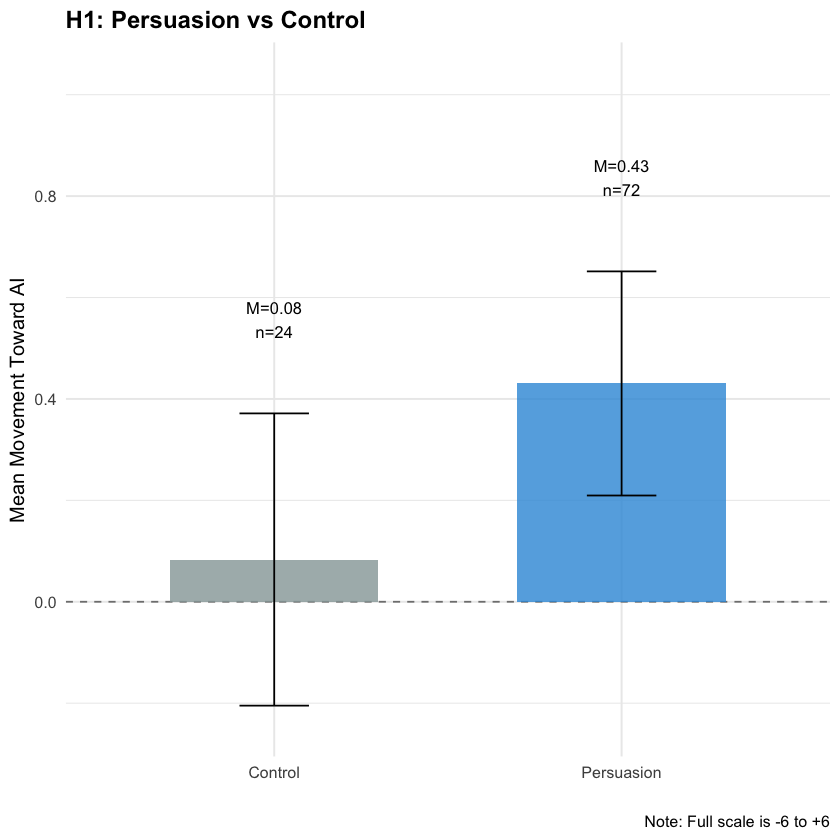

Saved: figures/h1_bar.png and figures/h1_table.png



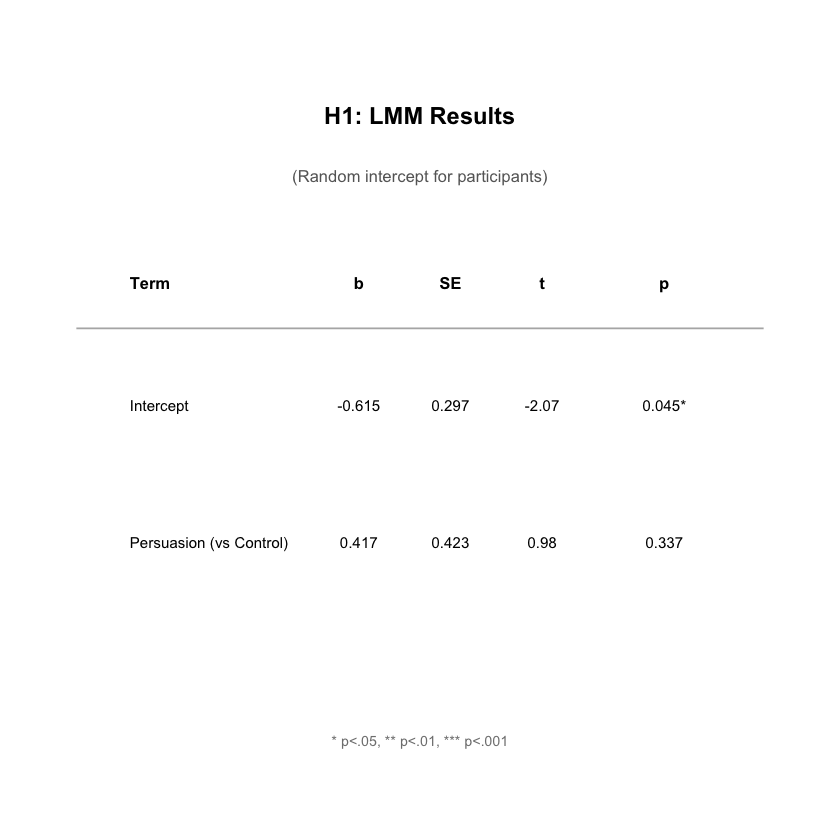

In [13]:
# H1: Persuasion vs Control
message("=== H1: PERSUASION VS CONTROL ===\n")

# ---------------------------------------------------------------------------
# H1, H2 and H3 are NESTED contrasts on the same four arms, so they come from
# ONE model fitted to all 24 participants.  The previous version fitted three
# separate models on shrinking subsets - H2 dropped the control arm, H3 dropped
# two arms and ran on 14 participants - which threw away data for no
# identification benefit, because the arms are randomised either way.
#
# is_opposing and is_claude are randomised causes of the outcome: NEUTRAL
# controls in the Cinelli/Forney/Pearl sense, included only to shrink the
# residual variance.  Nothing here blocks a backdoor path, because randomised
# exposures have no backdoor paths to block.
#
# The condition contrasts were set in the Data Preparation cell:
#   conditionC1_persuasion  = H1  control        vs any persuasion
#   conditionC2_personal    = H2  persuade       vs personalised
#   conditionC3_info        = H3  + demographics vs + personality
# ---------------------------------------------------------------------------

lmm_hyp <- lmer(movement_toward_ai ~ condition + is_opposing + is_claude +
                  (1 | participant_id), data = mixed_data)

# Unadjusted counterpart.  Report both: under randomisation the two should
# agree, and any movement between them is noise rather than deconfounding.
lmm_hyp_unadj <- lmer(movement_toward_ai ~ condition +
                        (1 | participant_id), data = mixed_data)

message("--- Adjusted model (source of H1, H2, H3 and the H6 stance term) ---")
print(round(summary(lmm_hyp)$coefficients, 3))
message("\n--- Unadjusted ---")
print(round(summary(lmm_hyp_unadj)$coefficients, 3))
message(sprintf("\nResidual variance: %.3f adjusted vs %.3f unadjusted",
                sigma(lmm_hyp)^2, sigma(lmm_hyp_unadj)^2))

# H1 contrast
h1_chat <- mixed_data
coef_h1 <- summary(lmm_hyp)$coefficients[c("(Intercept)", "conditionC1_persuasion"), ,
                                         drop = FALSE]
message("\nH1: control vs any persuasion")
print(round(coef_h1, 3))

h1_stats <- h1_chat %>%
  mutate(cond_label = ifelse(condition == "neutral", "Control", "Persuasion")) %>%
  group_by(cond_label) %>%
  summarise(n = n(), mean_mov = mean(movement_toward_ai), 
            se_mov = sd(movement_toward_ai) / sqrt(n()), .groups = "drop") %>%
  rename(condition = cond_label) %>%
  mutate(label_y = mean_mov + se_mov + 0.15)

p_h1_bar <- ggplot(h1_stats, aes(x = condition, y = mean_mov, fill = condition)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_mov - se_mov, ymax = mean_mov + se_mov), width = 0.2) +
  geom_text(aes(y = label_y, label = sprintf("M=%.2f\nn=%d", mean_mov, n)), vjust = 0, size = 3.5) +
  scale_fill_manual(values = c("Control" = "#95A5A6", "Persuasion" = "#3498DB")) +
  scale_y_continuous(expand = expansion(mult = c(0.1, 0.3))) +
  labs(title = "H1: Persuasion vs Control", x = "", y = "Mean Movement Toward AI",
       caption = "Note: Full scale is -6 to +6") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none", plot.title = element_text(face = "bold"))

print(p_h1_bar)
ggsave("figures/h1_bar.png", p_h1_bar, width = 6, height = 5, dpi = 150)

# Clean up term names
term_names <- rownames(coef_h1)
term_names <- gsub("conditionC1_persuasion", "Persuasion (vs Control)", term_names)
term_names <- gsub("\\(Intercept\\)", "Intercept", term_names)

lmm_tidy <- data.frame(Term = term_names, b = round(coef_h1[, 1], 3),
  SE = round(coef_h1[, 2], 3), t = round(coef_h1[, 4], 2), p = coef_h1[, 5]) %>%
  mutate(p_fmt = ifelse(p < 0.001, "<.001", sprintf("%.3f", p)),
         Sig = case_when(p < 0.001 ~ "***", p < 0.01 ~ "**", p < 0.05 ~ "*", p < 0.1 ~ "†", TRUE ~ ""))

p_h1_table <- ggplot() + theme_void() + xlim(0, 1) + ylim(0, 1) +
  annotate("text", x = 0.5, y = 0.9, label = "H1: LMM Results", size = 5, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.82, label = "(Random intercept for participants)", size = 3.5, color = "gray40") +
  annotate("text", x = 0.12, y = 0.68, label = "Term", size = 3.5, fontface = "bold", hjust = 0) +
  annotate("text", x = 0.42, y = 0.68, label = "b", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.54, y = 0.68, label = "SE", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.66, y = 0.68, label = "t", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.82, y = 0.68, label = "p", size = 3.5, fontface = "bold") +
  annotate("segment", x = 0.05, xend = 0.95, y = 0.62, yend = 0.62, color = "gray70")

for (j in 1:nrow(lmm_tidy)) {
  y_pos <- 0.52 - (j-1) * 0.18
  p_h1_table <- p_h1_table +
    annotate("text", x = 0.12, y = y_pos, label = lmm_tidy$Term[j], size = 3.2, hjust = 0) +
    annotate("text", x = 0.42, y = y_pos, label = lmm_tidy$b[j], size = 3.2) +
    annotate("text", x = 0.54, y = y_pos, label = lmm_tidy$SE[j], size = 3.2) +
    annotate("text", x = 0.66, y = y_pos, label = lmm_tidy$t[j], size = 3.2) +
    annotate("text", x = 0.82, y = y_pos, label = paste0(lmm_tidy$p_fmt[j], lmm_tidy$Sig[j]), size = 3.2)
}
p_h1_table <- p_h1_table + annotate("text", x = 0.5, y = 0.08, label = "* p<.05, ** p<.01, *** p<.001", size = 3, color = "gray50")

print(p_h1_table)
ggsave("figures/h1_table.png", p_h1_table, width = 6, height = 4, dpi = 150, bg = "white")
message("Saved: figures/h1_bar.png and figures/h1_table.png")


### H2: With Disclosure vs Without Disclosure
**Hypothesis**: Persuasion conditions with AI disclosure (info or demo) show different opinion change than basic persuasion without disclosure.

=== H2: PERSONALIZED VS NON-PERSONALIZED ===


Descriptives: 56 Personalized, 16 Non-Personalized observations


H2: persuade vs personalised (from lmm_hyp)



                     Estimate Std. Error     df t value Pr(>|t|)
(Intercept)            -0.615      0.297 37.691  -2.073    0.045
conditionC2_personal   -0.204      0.512 19.000  -0.398    0.695


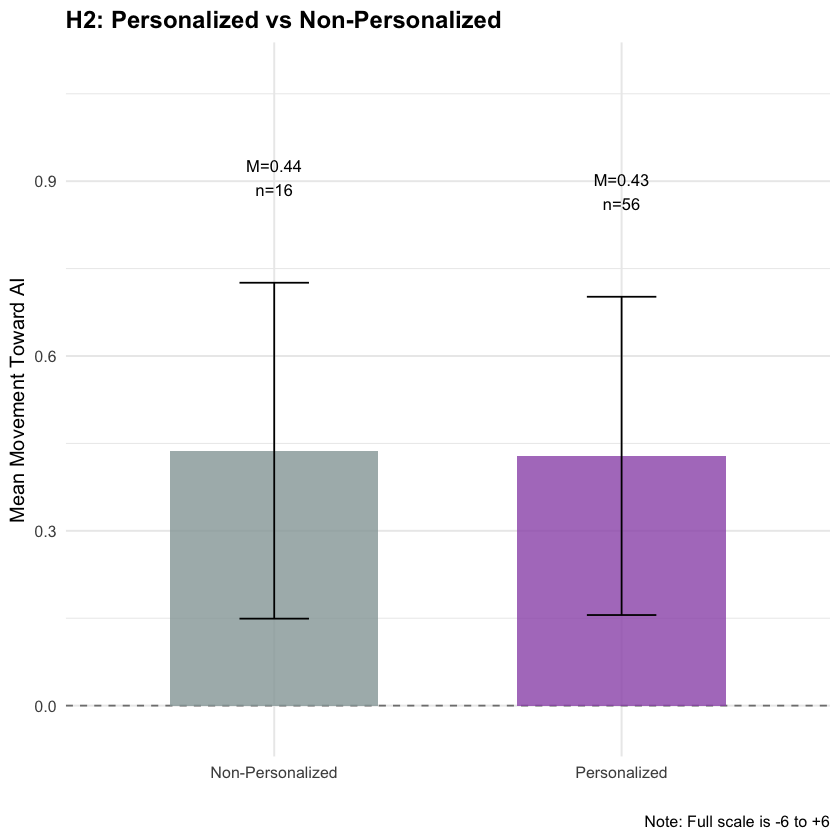

Saved: figures/h2_bar.png and figures/h2_table.png



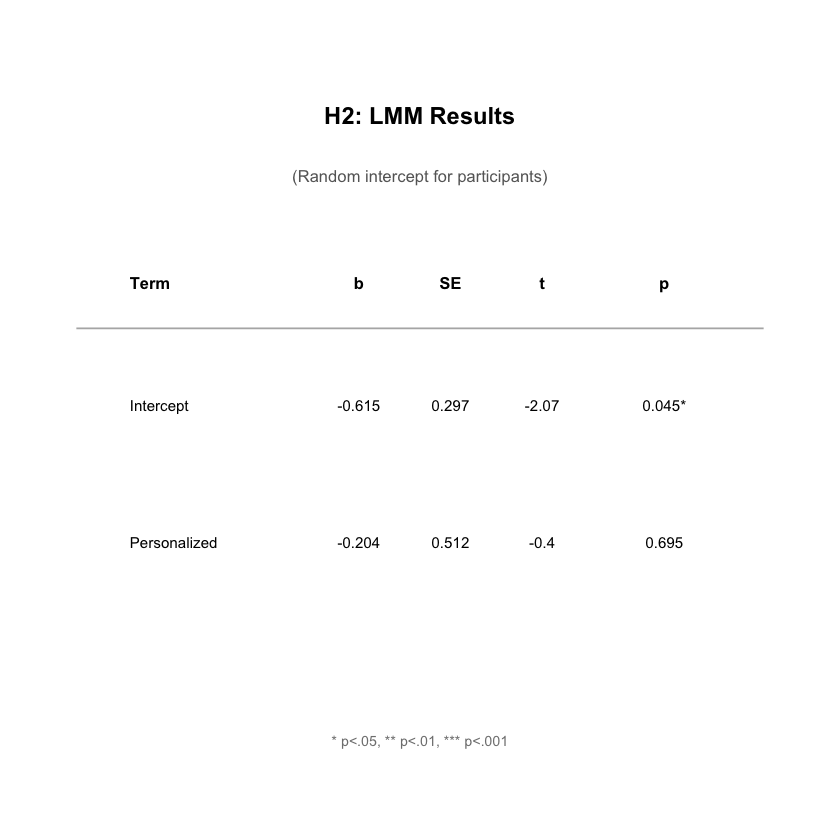

In [14]:
# H2: Personalized vs Non-Personalized
message("=== H2: PERSONALIZED VS NON-PERSONALIZED ===\n")

# Estimate comes from the shared model lmm_hyp fitted in the H1 cell, on all 24
# participants.  h2_data is used only for the descriptive means in the plot.
h2_data <- mixed_data %>%
  filter(condition != "neutral") %>%
  mutate(is_personalized = ifelse(condition %in% c("persuade_demo", "persuade_info"), 1, 0))

message(sprintf("Descriptives: %d Personalized, %d Non-Personalized observations",
                sum(h2_data$is_personalized == 1),
                sum(h2_data$is_personalized == 0)))

coef_h2 <- summary(lmm_hyp)$coefficients[c("(Intercept)", "conditionC2_personal"), ,
                                         drop = FALSE]
message("\nH2: persuade vs personalised (from lmm_hyp)")
print(round(coef_h2, 3))

h2_stats <- h2_data %>%
  group_by(is_personalized) %>%
  summarise(n = n(), mean_mov = mean(movement_toward_ai), 
            se_mov = sd(movement_toward_ai) / sqrt(n()), .groups = "drop") %>%
  mutate(condition = ifelse(is_personalized == 1, "Personalized", "Non-Personalized"),
         label_y = mean_mov + se_mov + 0.15)

p_h2_bar <- ggplot(h2_stats, aes(x = condition, y = mean_mov, fill = condition)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_mov - se_mov, ymax = mean_mov + se_mov), width = 0.2) +
  geom_text(aes(y = label_y, label = sprintf("M=%.2f\nn=%d", mean_mov, n)), vjust = 0, size = 3.5) +
  scale_fill_manual(values = c("Non-Personalized" = "#95A5A6", "Personalized" = "#9B59B6")) +
  scale_y_continuous(expand = expansion(mult = c(0.1, 0.3))) +
  labs(title = "H2: Personalized vs Non-Personalized", x = "", y = "Mean Movement Toward AI",
       caption = "Note: Full scale is -6 to +6") +
  theme_minimal(base_size = 12) + theme(legend.position = "none", plot.title = element_text(face = "bold"))

print(p_h2_bar)
ggsave("figures/h2_bar.png", p_h2_bar, width = 6, height = 5, dpi = 150)

# Clean up term names
term_names <- rownames(coef_h2)
term_names <- gsub("conditionC2_personal", "Personalized", term_names)
term_names <- gsub("\\(Intercept\\)", "Intercept", term_names)

lmm_tidy <- data.frame(Term = term_names, b = round(coef_h2[, 1], 3),
  SE = round(coef_h2[, 2], 3), t = round(coef_h2[, 4], 2), p = coef_h2[, 5]) %>%
  mutate(p_fmt = ifelse(p < 0.001, "<.001", sprintf("%.3f", p)),
         Sig = case_when(p < 0.001 ~ "***", p < 0.01 ~ "**", p < 0.05 ~ "*", p < 0.1 ~ "†", TRUE ~ ""))

p_h2_table <- ggplot() + theme_void() + xlim(0, 1) + ylim(0, 1) +
  annotate("text", x = 0.5, y = 0.9, label = "H2: LMM Results", size = 5, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.82, label = "(Random intercept for participants)", size = 3.5, color = "gray40") +
  annotate("text", x = 0.12, y = 0.68, label = "Term", size = 3.5, fontface = "bold", hjust = 0) +
  annotate("text", x = 0.42, y = 0.68, label = "b", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.54, y = 0.68, label = "SE", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.66, y = 0.68, label = "t", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.82, y = 0.68, label = "p", size = 3.5, fontface = "bold") +
  annotate("segment", x = 0.05, xend = 0.95, y = 0.62, yend = 0.62, color = "gray70")

for (j in 1:nrow(lmm_tidy)) {
  y_pos <- 0.52 - (j-1) * 0.18
  p_h2_table <- p_h2_table +
    annotate("text", x = 0.12, y = y_pos, label = lmm_tidy$Term[j], size = 3.2, hjust = 0) +
    annotate("text", x = 0.42, y = y_pos, label = lmm_tidy$b[j], size = 3.2) +
    annotate("text", x = 0.54, y = y_pos, label = lmm_tidy$SE[j], size = 3.2) +
    annotate("text", x = 0.66, y = y_pos, label = lmm_tidy$t[j], size = 3.2) +
    annotate("text", x = 0.82, y = y_pos, label = paste0(lmm_tidy$p_fmt[j], lmm_tidy$Sig[j]), size = 3.2)
}
p_h2_table <- p_h2_table + annotate("text", x = 0.5, y = 0.08, label = "* p<.05, ** p<.01, *** p<.001", size = 3, color = "gray50")

print(p_h2_table)
ggsave("figures/h2_table.png", p_h2_table, width = 6, height = 4, dpi = 150, bg = "white")
message("Saved: figures/h2_bar.png and figures/h2_table.png")


### H3: Persuade + Demo + Info vs Persuade + Demo
**Hypothesis**: Participants in the persuade_info condition will exhibit larger changes than participants in the persuade_demo condition.

=== H3: INFO VS DEMO DISCLOSURE ===



H3: + demographics vs + demographics & personality (from lmm_hyp)



                 Estimate Std. Error     df t value Pr(>|t|)
(Intercept)        -0.615      0.297 37.691  -2.073    0.045
conditionC3_info   -0.052      0.479 19.000  -0.109    0.915


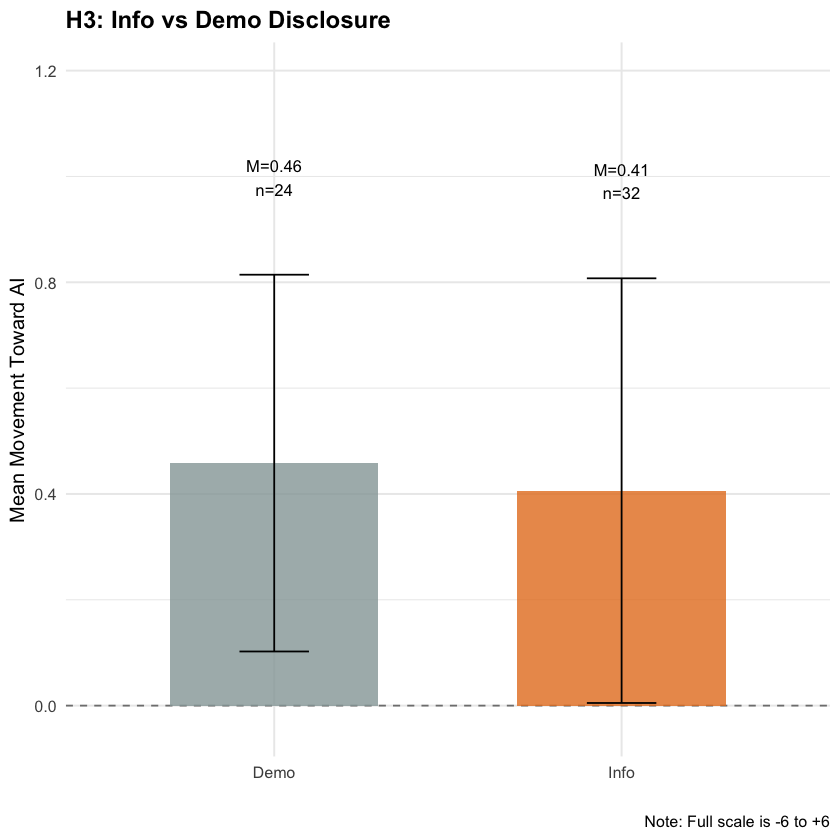

Saved: figures/h3_bar.png and figures/h3_table.png



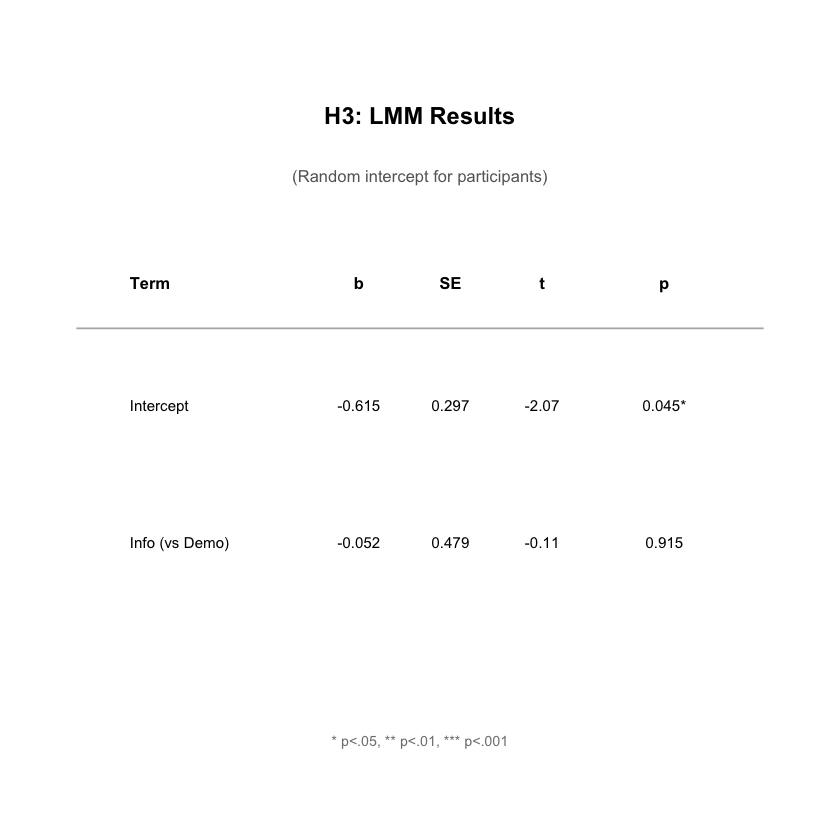

In [15]:
# H3: Info vs Demo Disclosure
message("=== H3: INFO VS DEMO DISCLOSURE ===\n")

# Estimate comes from the shared model lmm_hyp.  Fitting H3 on its own subset
# used 14 of 24 participants; the nested contrast uses all 24.
h3_data <- mixed_data %>%
  filter(condition %in% c("persuade_demo", "persuade_info")) %>%
  mutate(disclosure = factor(ifelse(condition == "persuade_info", "Info", "Demo"),
                             levels = c("Demo", "Info")))

coef_h3 <- summary(lmm_hyp)$coefficients[c("(Intercept)", "conditionC3_info"), ,
                                         drop = FALSE]
message("\nH3: + demographics vs + demographics & personality (from lmm_hyp)")
print(round(coef_h3, 3))

h3_stats <- h3_data %>%
  group_by(disclosure) %>%
  summarise(n = n(), mean_mov = mean(movement_toward_ai), 
            se_mov = sd(movement_toward_ai) / sqrt(n()), .groups = "drop") %>%
  rename(condition = disclosure) %>%
  mutate(label_y = mean_mov + se_mov + 0.15)

p_h3_bar <- ggplot(h3_stats, aes(x = condition, y = mean_mov, fill = condition)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_mov - se_mov, ymax = mean_mov + se_mov), width = 0.2) +
  geom_text(aes(y = label_y, label = sprintf("M=%.2f\nn=%d", mean_mov, n)), vjust = 0, size = 3.5) +
  scale_fill_manual(values = c("Demo" = "#95A5A6", "Info" = "#E67E22")) +
  scale_y_continuous(expand = expansion(mult = c(0.1, 0.3))) +
  labs(title = "H3: Info vs Demo Disclosure", x = "", y = "Mean Movement Toward AI",
       caption = "Note: Full scale is -6 to +6") +
  theme_minimal(base_size = 12) + theme(legend.position = "none", plot.title = element_text(face = "bold"))

print(p_h3_bar)
ggsave("figures/h3_bar.png", p_h3_bar, width = 6, height = 5, dpi = 150)

# Clean up term names
term_names <- rownames(coef_h3)
term_names <- gsub("conditionC3_info", "Info (vs Demo)", term_names)
term_names <- gsub("\\(Intercept\\)", "Intercept", term_names)

lmm_tidy <- data.frame(Term = term_names, b = round(coef_h3[, 1], 3),
  SE = round(coef_h3[, 2], 3), t = round(coef_h3[, 4], 2), p = coef_h3[, 5]) %>%
  mutate(p_fmt = ifelse(p < 0.001, "<.001", sprintf("%.3f", p)),
         Sig = case_when(p < 0.001 ~ "***", p < 0.01 ~ "**", p < 0.05 ~ "*", p < 0.1 ~ "†", TRUE ~ ""))

p_h3_table <- ggplot() + theme_void() + xlim(0, 1) + ylim(0, 1) +
  annotate("text", x = 0.5, y = 0.9, label = "H3: LMM Results", size = 5, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.82, label = "(Random intercept for participants)", size = 3.5, color = "gray40") +
  annotate("text", x = 0.12, y = 0.68, label = "Term", size = 3.5, fontface = "bold", hjust = 0) +
  annotate("text", x = 0.42, y = 0.68, label = "b", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.54, y = 0.68, label = "SE", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.66, y = 0.68, label = "t", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.82, y = 0.68, label = "p", size = 3.5, fontface = "bold") +
  annotate("segment", x = 0.05, xend = 0.95, y = 0.62, yend = 0.62, color = "gray70")

for (j in 1:nrow(lmm_tidy)) {
  y_pos <- 0.52 - (j-1) * 0.18
  p_h3_table <- p_h3_table +
    annotate("text", x = 0.12, y = y_pos, label = lmm_tidy$Term[j], size = 3.2, hjust = 0) +
    annotate("text", x = 0.42, y = y_pos, label = lmm_tidy$b[j], size = 3.2) +
    annotate("text", x = 0.54, y = y_pos, label = lmm_tidy$SE[j], size = 3.2) +
    annotate("text", x = 0.66, y = y_pos, label = lmm_tidy$t[j], size = 3.2) +
    annotate("text", x = 0.82, y = y_pos, label = paste0(lmm_tidy$p_fmt[j], lmm_tidy$Sig[j]), size = 3.2)
}
p_h3_table <- p_h3_table + annotate("text", x = 0.5, y = 0.08, label = "* p<.05, ** p<.01, *** p<.001", size = 3, color = "gray50")

print(p_h3_table)
ggsave("figures/h3_table.png", p_h3_table, width = 6, height = 4, dpi = 150, bg = "white")
message("Saved: figures/h3_bar.png and figures/h3_table.png")


### H4: Initial Rating Extremity
**Hypothesis**: Participants with initial ratings closer to the midpoint (4) will exhibit larger changes than participants with more extreme initial judgments.

Expected: Negative coefficient for extremity (more extreme → less change).

=== H4: INITIAL OPINION EXTREMITY ===


--- MODEL 1: Extremity -> Movement toward AI, by stance ---



                        Estimate Std. Error     df t value Pr(>|t|)
(Intercept)               -0.632      0.304 35.509  -2.078    0.045
is_opposing                1.239      0.337 68.382   3.676    0.000
extremity_w               -0.062      0.260 81.977  -0.237    0.813
extremity_b               -0.267      0.557 48.759  -0.480    0.634
conditionC1_persuasion     0.424      0.433 18.054   0.980    0.340
conditionC2_personal      -0.158      0.539 18.105  -0.292    0.773
conditionC3_info          -0.038      0.488 17.943  -0.078    0.939
is_claude                  0.832      0.379 18.142   2.192    0.042
is_opposing:extremity_w    0.233      0.375 85.785   0.621    0.536
is_opposing:extremity_b    0.022      0.734 68.382   0.030    0.976



Within-participant extremity: b=-0.062, SE=0.260, t=-0.24, p=0.8133

Extremity x opposing stance : b=0.233, SE=0.375, t=0.62, p=0.5360


--- Pooled specification (same DV, no stance split) ---



            Estimate Std. Error     df t value Pr(>|t|)
(Intercept)    0.414      0.368 83.747   1.124    0.264
extremity     -0.038      0.174 92.261  -0.221    0.826



--- Original specification (abs_change ~ extremity) ---



            Estimate Std. Error     df t value Pr(>|t|)
(Intercept)    1.655      0.296 83.677   5.599     0.00
extremity     -0.331      0.140 92.112  -2.371     0.02



--- MODEL 2: RTM Test (rating_pre_centered -> rating_change) ---

b=-0.260, SE=0.085, t=-3.07, p=0.0028


-> RTM DETECTED: Initial position negatively predicts change direction

   High ratings move down, low ratings move up (toward mean)



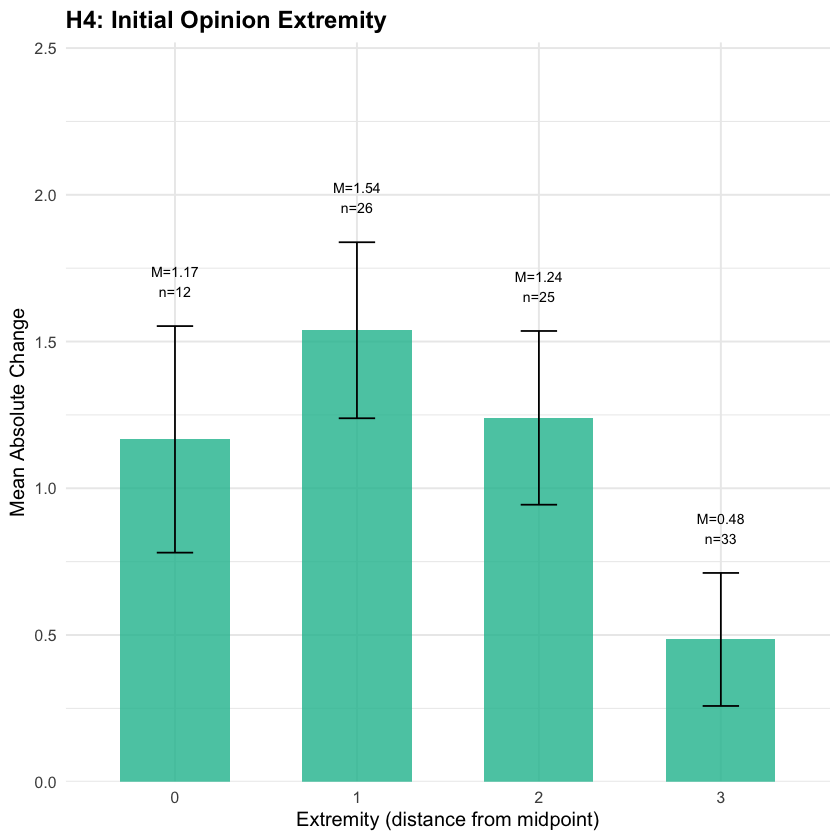


Saved: figures/h4_bar.png and figures/h4_table.png



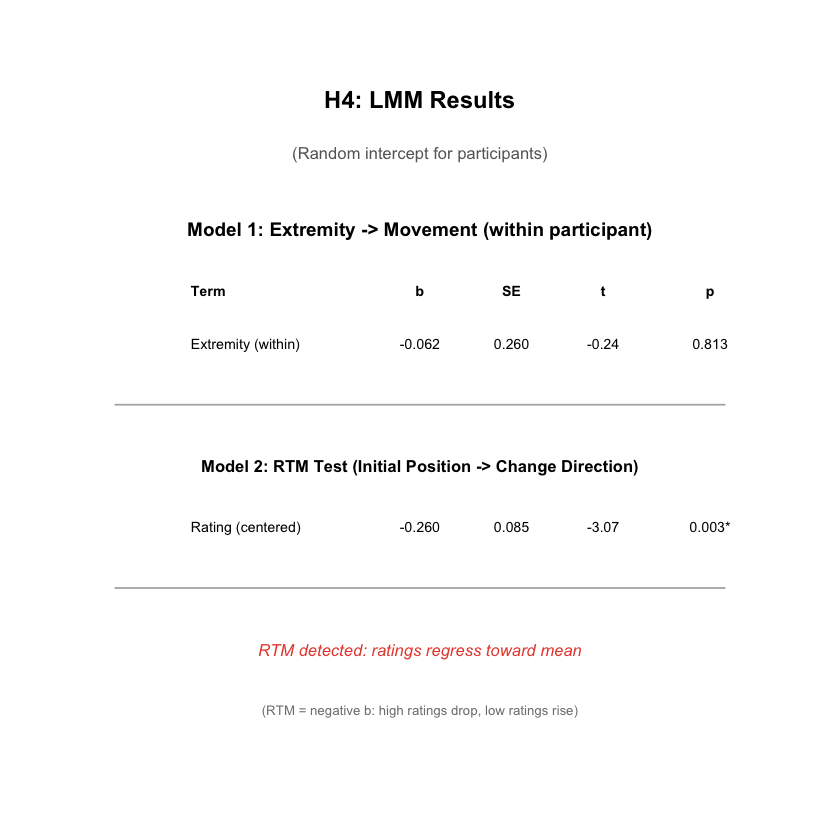

In [16]:
# H4: Initial Opinion Extremity
message("=== H4: INITIAL OPINION EXTREMITY ===\n")

h4_data <- mixed_data

# ============================================
# MODEL 1: the H4 test.  Two corrections to the previous specification.
# --------------------------------------------
# (a) THE STANCE INTERACTION IS STRUCTURAL, NOT EXPLORATORY.
#     On a 1-7 scale the room available to move toward the AI is
#         3 + extremity  when the AI OPPOSES the participant
#         3 - extremity  when the AI REINFORCES them
#     (verified TRUE for all 96 conversations).  Extremity therefore has
#     mechanically OPPOSITE relations to the outcome in the two stance groups,
#     and a single pooled slope averages them toward zero regardless of what is
#     really happening.  The interaction is required for the coefficient to mean
#     anything.
#
# (b) EXTREMITY IS THE ONE EXPOSURE THAT IS NOT RANDOMISED.
#     Participants brought their baseline ratings with them, so this is the only
#     hypothesis where a genuine confounder strategy is needed - dagitty returns
#     {Demographics, DilemmaFeat, Personality} as the adjustment set.  Rather
#     than adjust for the confounders that happen to have been measured,
#     extremity is split into a within- and a between-participant component.
#     extremity_w is the identified estimate: it is free of EVERY time-invariant
#     participant confounder, measured or not.  extremity_b is the
#     between-participant part and remains open to confounding - report it as
#     descriptive.
# ============================================
message("--- MODEL 1: Extremity -> Movement toward AI, by stance ---")
lmm_h4 <- lmer(movement_toward_ai ~ is_opposing * extremity_w +
                 is_opposing * extremity_b + condition + is_claude +
                 (1 | participant_id), data = h4_data)
print(round(summary(lmm_h4)$coefficients, 3))

coef_h4_full <- summary(lmm_h4)$coefficients
coef_h4 <- coef_h4_full[c("(Intercept)", "extremity_w"), , drop = FALSE]

message(sprintf("\nWithin-participant extremity: b=%.3f, SE=%.3f, t=%.2f, p=%.4f",
                coef_h4_full["extremity_w", 1], coef_h4_full["extremity_w", 2],
                coef_h4_full["extremity_w", 4], coef_h4_full["extremity_w", 5]))
message(sprintf("Extremity x opposing stance : b=%.3f, SE=%.3f, t=%.2f, p=%.4f",
                coef_h4_full["is_opposing:extremity_w", 1],
                coef_h4_full["is_opposing:extremity_w", 2],
                coef_h4_full["is_opposing:extremity_w", 4],
                coef_h4_full["is_opposing:extremity_w", 5]))

# Pooled counterpart on the SAME outcome: one extremity slope, no stance split
# and no within/between decomposition.  Comparing it with Model 1 shows what the
# bounded scale hides - the pooled slope is the average of two opposite
# mechanical relations, so it is near zero whatever is really going on.
lmm_h4_unadj <- lmer(movement_toward_ai ~ extremity + (1 | participant_id),
                     data = h4_data)
message("\n--- Pooled specification (same DV, no stance split) ---")
print(round(summary(lmm_h4_unadj)$coefficients, 3))

# The notebook's original H4 model, on absolute change, kept for reference.
lmm_h4_prev <- lmer(abs_change ~ extremity + (1 | participant_id), data = h4_data)
message("\n--- Original specification (abs_change ~ extremity) ---")
print(round(summary(lmm_h4_prev)$coefficients, 3))

# ============================================
# MODEL 2: RTM Test - does initial position predict direction of change?
# This is a DIAGNOSTIC, not a causal estimate: regression to the mean is a
# property of the measurement, so no adjustment set applies.
# RTM predicts: high ratings -> negative change, low ratings -> positive change,
# so rating_pre_centered should NEGATIVELY predict rating_change.
# ============================================
message("\n--- MODEL 2: RTM Test (rating_pre_centered -> rating_change) ---")
lmm_rtm <- lmer(rating_change ~ rating_pre_centered + (1 | participant_id), data = h4_data)
coef_rtm <- summary(lmm_rtm)$coefficients
message(sprintf("b=%.3f, SE=%.3f, t=%.2f, p=%.4f",
                coef_rtm["rating_pre_centered", 1], coef_rtm["rating_pre_centered", 2],
                coef_rtm["rating_pre_centered", 4], coef_rtm["rating_pre_centered", 5]))

# Interpretation
if (coef_rtm["rating_pre_centered", 5] < 0.05 && coef_rtm["rating_pre_centered", 1] < 0) {
  message("\n-> RTM DETECTED: Initial position negatively predicts change direction")
  message("   High ratings move down, low ratings move up (toward mean)")
} else if (coef_rtm["rating_pre_centered", 5] >= 0.05) {
  message("\n-> NO RTM: Initial position does not predict change direction")
} else {
  message("\n-> ANTI-RTM: Initial position positively predicts change (polarization?)")
}

# Stats by extremity level
h4_stats <- h4_data %>%
  group_by(extremity) %>%
  summarise(n = n(), mean_abs = mean(abs_change), 
            se_abs = sd(abs_change) / sqrt(n()), .groups = "drop") %>%
  mutate(label_y = mean_abs + se_abs + 0.1)

# Bar chart
p_h4_bar <- ggplot(h4_stats, aes(x = factor(extremity), y = mean_abs)) +
  geom_col(width = 0.6, fill = "#1ABC9C", alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_abs - se_abs, ymax = mean_abs + se_abs), width = 0.2) +
  geom_text(aes(y = label_y, label = sprintf("M=%.2f\nn=%d", mean_abs, n)), vjust = 0, size = 3) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.3))) +
  labs(title = "H4: Initial Opinion Extremity", x = "Extremity (distance from midpoint)", 
       y = "Mean Absolute Change") +
  theme_minimal(base_size = 12) + theme(plot.title = element_text(face = "bold"))

print(p_h4_bar)
ggsave("figures/h4_bar.png", p_h4_bar, width = 6, height = 5, dpi = 150)

# Table
p_h4_table <- ggplot() + theme_void() + xlim(0, 1) + ylim(0, 1) +
  annotate("text", x = 0.5, y = 0.92, label = "H4: LMM Results", size = 5, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.85, label = "(Random intercept for participants)", size = 3.5, color = "gray40") +
  
  # Model 1
  annotate("text", x = 0.5, y = 0.75, label = "Model 1: Extremity -> Movement (within participant)", size = 4, fontface = "bold") +
  annotate("text", x = 0.20, y = 0.67, label = "Term", size = 3, fontface = "bold", hjust = 0) +
  annotate("text", x = 0.50, y = 0.67, label = "b", size = 3, fontface = "bold") +
  annotate("text", x = 0.62, y = 0.67, label = "SE", size = 3, fontface = "bold") +
  annotate("text", x = 0.74, y = 0.67, label = "t", size = 3, fontface = "bold") +
  annotate("text", x = 0.88, y = 0.67, label = "p", size = 3, fontface = "bold") +
  annotate("text", x = 0.20, y = 0.60, label = "Extremity (within)", size = 3, hjust = 0) +
  annotate("text", x = 0.50, y = 0.60, label = sprintf("%.3f", coef_h4[2, 1]), size = 3) +
  annotate("text", x = 0.62, y = 0.60, label = sprintf("%.3f", coef_h4[2, 2]), size = 3) +
  annotate("text", x = 0.74, y = 0.60, label = sprintf("%.2f", coef_h4[2, 4]), size = 3) +
  annotate("text", x = 0.88, y = 0.60, label = ifelse(coef_h4[2, 5] < 0.001, "<.001", 
           sprintf("%.3f%s", coef_h4[2, 5], ifelse(coef_h4[2, 5] < 0.05, "*", ""))), size = 3) +
  
  annotate("segment", x = 0.1, xend = 0.9, y = 0.52, yend = 0.52, color = "gray70") +
  
  # Model 2: RTM test
  annotate("text", x = 0.5, y = 0.44, label = "Model 2: RTM Test (Initial Position -> Change Direction)", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.20, y = 0.36, label = "Rating (centered)", size = 3, hjust = 0) +
  annotate("text", x = 0.50, y = 0.36, label = sprintf("%.3f", coef_rtm[2, 1]), size = 3) +
  annotate("text", x = 0.62, y = 0.36, label = sprintf("%.3f", coef_rtm[2, 2]), size = 3) +
  annotate("text", x = 0.74, y = 0.36, label = sprintf("%.2f", coef_rtm[2, 4]), size = 3) +
  annotate("text", x = 0.88, y = 0.36, label = ifelse(coef_rtm[2, 5] < 0.001, "<.001", 
           sprintf("%.3f%s", coef_rtm[2, 5], ifelse(coef_rtm[2, 5] < 0.05, "*", ""))), size = 3) +
  
  annotate("segment", x = 0.1, xend = 0.9, y = 0.28, yend = 0.28, color = "gray70") +
  
  # Interpretation
  annotate("text", x = 0.5, y = 0.20, 
           label = ifelse(coef_rtm[2, 5] < 0.05 && coef_rtm[2, 1] < 0,
                         "RTM detected: ratings regress toward mean",
                         ifelse(coef_rtm[2, 5] >= 0.05,
                                "No RTM: initial position does not predict direction",
                                "Anti-RTM: opinions polarize")),
           size = 3.5, fontface = "italic",
           color = ifelse(coef_rtm[2, 5] < 0.05 && coef_rtm[2, 1] < 0, "#E74C3C", "#27AE60")) +
  annotate("text", x = 0.5, y = 0.12,
           label = "(RTM = negative b: high ratings drop, low ratings rise)",
           size = 2.8, color = "gray50")

print(p_h4_table)
ggsave("figures/h4_table.png", p_h4_table, width = 7, height = 6, dpi = 150, bg = "white")
message("\nSaved: figures/h4_bar.png and figures/h4_table.png")

### H5: Discussed vs Undiscussed Dilemmas
**Hypothesis**: Dilemmas discussed with AI show greater opinion change than undiscussed dilemmas.

=== H5: DISCUSSED VS UNDISCUSSED (WITHIN-PARTICIPANT) ===


--- Adjusted ---



                       Estimate Std. Error      df t value Pr(>|t|)
(Intercept)               1.171      0.231  63.633   5.062    0.000
had_chatTRUE              0.362      0.159 159.900   2.276    0.024
conditionC1_persuasion   -0.038      0.321  19.694  -0.118    0.908
conditionC2_personal      0.550      0.384  19.922   1.431    0.168
conditionC3_info          0.255      0.365  19.724   0.700    0.492
extremity                -0.262      0.085 167.346  -3.088    0.002



--- Unadjusted ---



             Estimate Std. Error      df t value Pr(>|t|)
(Intercept)     0.719      0.158  43.778   4.559    0.000
had_chatTRUE    0.333      0.168 167.000   1.988    0.048



Dilemma variance (192 ratings): 0.0841 - non-zero here, unlike the
96-conversation models where it is singular.

--- MAGNITUDE (Mean Absolute Change) ---


Participants with both conditions: 24

Paired t-test (magnitude): t=2.241, df=23, p=0.0349

Mean difference: 0.333


--- LIKELIHOOD (Proportion Changed) ---


Paired t-test (likelihood): t=0.310, df=23, p=0.7592

Mean % changed - Discussed: 45.8%, Undiscussed: 43.8%



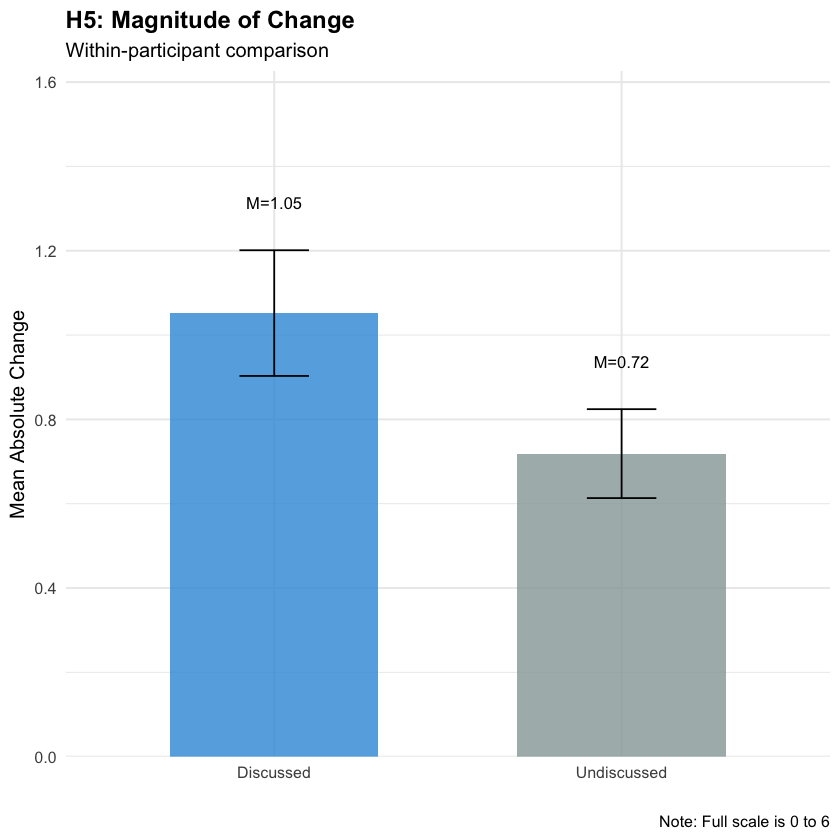

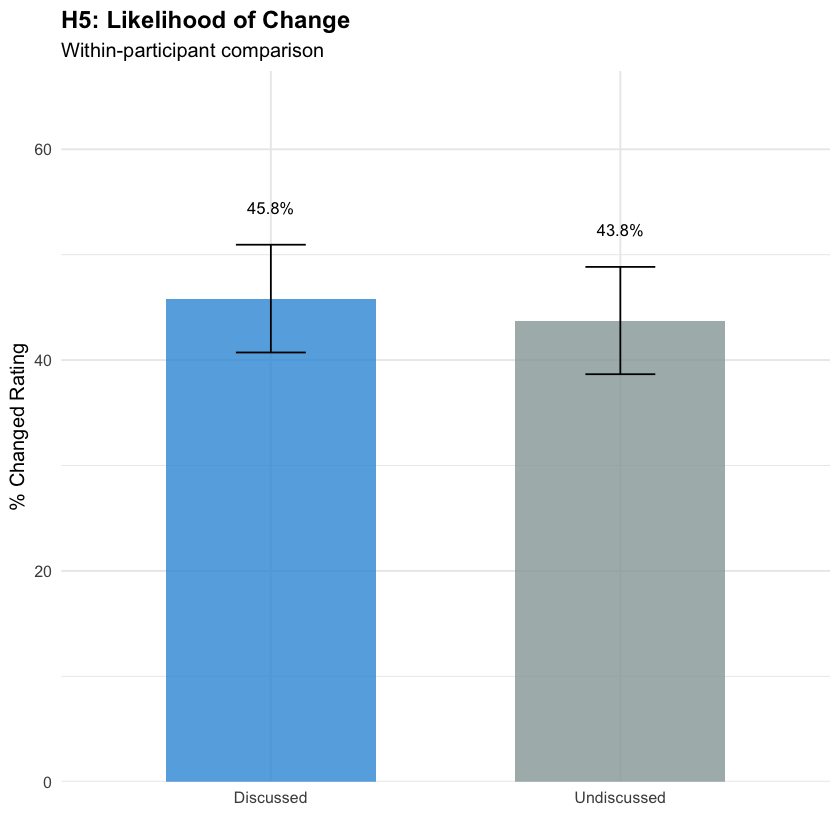


Saved: figures/h5_magnitude_bar.png, figures/h5_likelihood_bar.png, figures/h5_table.png



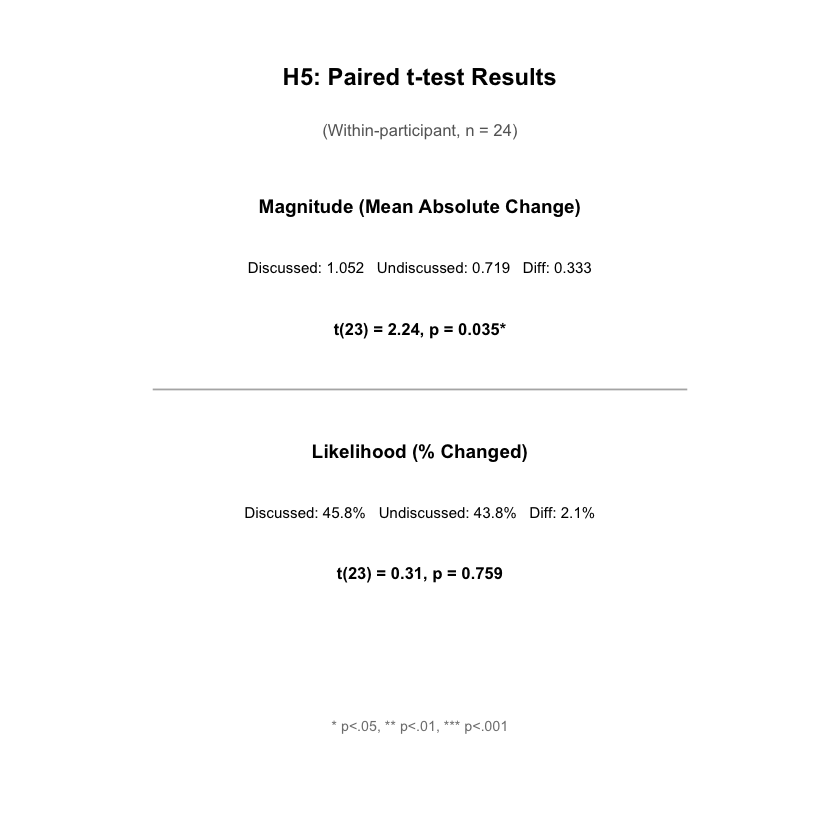

In [17]:
# H5: Discussed vs Undiscussed (Within-Participant)
message("=== H5: DISCUSSED VS UNDISCUSSED (WITHIN-PARTICIPANT) ===\n")

# All 192 ratings, including the 96 undiscussed dilemmas.
# movement_toward_ai is undefined without an AI stance, so the outcome here is
# the MAGNITUDE of change.  had_chat varies within participant (each participant
# discussed 4 of their 8 rated dilemmas), so the participant random intercept
# carries the contrast and no between-participant confounder can bias it.
# Selection into discussion is balanced: 48/48 by dilemma author and extremity
# does not differ between discussed and undiscussed ratings (p = .33).
h5_data <- long_data %>%
  mutate(did_change = rating_change != 0)

# ---------------------------------------------------------------------------
# Mixed model (primary test).  Extremity is a pre-exposure cause of the outcome
# and dilemma identity is estimable here because all 192 ratings are used, so
# both enter as neutral controls for precision.
# ---------------------------------------------------------------------------
lmm_h5       <- lmer(abs_change ~ had_chat + condition + extremity +
                       (1 | participant_id) + (1 | dilemma), data = h5_data)
lmm_h5_unadj <- lmer(abs_change ~ had_chat + (1 | participant_id), data = h5_data)

message("--- Adjusted ---")
print(round(summary(lmm_h5)$coefficients, 3))
message("\n--- Unadjusted ---")
print(round(summary(lmm_h5_unadj)$coefficients, 3))
coef_h5 <- summary(lmm_h5)$coefficients

vc_h5 <- as.data.frame(VarCorr(lmm_h5))
message(sprintf("\nDilemma variance (192 ratings): %.4f - non-zero here, unlike the\n96-conversation models where it is singular.",
                vc_h5$vcov[vc_h5$grp == "dilemma"]))

# ============================================
# MAGNITUDE: Mean absolute change
# ============================================
message("--- MAGNITUDE (Mean Absolute Change) ---\n")

h5_magnitude <- h5_data %>%
  group_by(participant_id, had_chat) %>%
  summarise(mean_change = mean(abs_change), .groups = "drop") %>%
  pivot_wider(names_from = had_chat, values_from = mean_change, 
              names_prefix = "chat_") %>%
  filter(!is.na(chat_TRUE) & !is.na(chat_FALSE))

message(sprintf("Participants with both conditions: %d", nrow(h5_magnitude)))

paired_magnitude <- t.test(h5_magnitude$chat_TRUE, h5_magnitude$chat_FALSE, paired = TRUE)
message(sprintf("Paired t-test (magnitude): t=%.3f, df=%d, p=%.4f", 
                paired_magnitude$statistic, paired_magnitude$parameter, paired_magnitude$p.value))
message(sprintf("Mean difference: %.3f", paired_magnitude$estimate))

# ============================================
# LIKELIHOOD: Proportion who changed
# ============================================
message("\n--- LIKELIHOOD (Proportion Changed) ---\n")

h5_likelihood <- h5_data %>%
  group_by(participant_id, had_chat) %>%
  summarise(pct_changed = mean(did_change), .groups = "drop") %>%
  pivot_wider(names_from = had_chat, values_from = pct_changed, 
              names_prefix = "chat_") %>%
  filter(!is.na(chat_TRUE) & !is.na(chat_FALSE))

paired_likelihood <- t.test(h5_likelihood$chat_TRUE, h5_likelihood$chat_FALSE, paired = TRUE)
message(sprintf("Paired t-test (likelihood): t=%.3f, df=%d, p=%.4f", 
                paired_likelihood$statistic, paired_likelihood$parameter, paired_likelihood$p.value))
message(sprintf("Mean %% changed - Discussed: %.1f%%, Undiscussed: %.1f%%", 
                mean(h5_likelihood$chat_TRUE) * 100, mean(h5_likelihood$chat_FALSE) * 100))

# Summary stats for plot
h5_stats_mag <- h5_data %>%
  group_by(had_chat) %>%
  summarise(n = n(), mean_val = mean(abs_change), 
            se_val = sd(abs_change) / sqrt(n()), .groups = "drop") %>%
  mutate(condition = ifelse(had_chat, "Discussed", "Undiscussed"),
         label_y = mean_val + se_val + 0.1,
         metric = "Mean Absolute Change")

h5_stats_lik <- h5_data %>%
  group_by(had_chat) %>%
  summarise(n = n(), mean_val = mean(did_change) * 100, 
            se_val = sd(did_change) / sqrt(n()) * 100, .groups = "drop") %>%
  mutate(condition = ifelse(had_chat, "Discussed", "Undiscussed"),
         label_y = mean_val + se_val + 3,
         metric = "% Changed")

# Magnitude bar chart
p_h5_mag <- ggplot(h5_stats_mag, aes(x = condition, y = mean_val, fill = condition)) +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_val - se_val, ymax = mean_val + se_val), width = 0.2) +
  geom_text(aes(y = label_y, label = sprintf("M=%.2f", mean_val)), vjust = 0, size = 3.5) +
  scale_fill_manual(values = c("Discussed" = "#3498DB", "Undiscussed" = "#95A5A6")) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.25))) +
  labs(title = "H5: Magnitude of Change", 
       subtitle = "Within-participant comparison",
       x = "", y = "Mean Absolute Change",
       caption = "Note: Full scale is 0 to 6") +
  theme_minimal(base_size = 12) + theme(legend.position = "none", plot.title = element_text(face = "bold"))

print(p_h5_mag)
ggsave("figures/h5_magnitude_bar.png", p_h5_mag, width = 6, height = 5, dpi = 150)

# Likelihood bar chart
p_h5_lik <- ggplot(h5_stats_lik, aes(x = condition, y = mean_val, fill = condition)) +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_val - se_val, ymax = mean_val + se_val), width = 0.2) +
  geom_text(aes(y = label_y, label = sprintf("%.1f%%", mean_val)), vjust = 0, size = 3.5) +
  scale_fill_manual(values = c("Discussed" = "#3498DB", "Undiscussed" = "#95A5A6")) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.25))) +
  labs(title = "H5: Likelihood of Change", 
       subtitle = "Within-participant comparison",
       x = "", y = "% Changed Rating") +
  theme_minimal(base_size = 12) + theme(legend.position = "none", plot.title = element_text(face = "bold"))

print(p_h5_lik)
ggsave("figures/h5_likelihood_bar.png", p_h5_lik, width = 6, height = 5, dpi = 150)

# Combined table with both tests
sig_mag <- ifelse(paired_magnitude$p.value < 0.001, "***", ifelse(paired_magnitude$p.value < 0.01, "**",
            ifelse(paired_magnitude$p.value < 0.05, "*", ifelse(paired_magnitude$p.value < 0.1, "†", ""))))
sig_lik <- ifelse(paired_likelihood$p.value < 0.001, "***", ifelse(paired_likelihood$p.value < 0.01, "**",
            ifelse(paired_likelihood$p.value < 0.05, "*", ifelse(paired_likelihood$p.value < 0.1, "†", ""))))

p_h5_table <- ggplot() + theme_void() + xlim(0, 1) + ylim(0, 1) +
  annotate("text", x = 0.5, y = 0.95, label = "H5: Paired t-test Results", size = 5, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.88, label = sprintf("(Within-participant, n = %d)", nrow(h5_magnitude)), size = 3.5, color = "gray40") +
  
  # Magnitude section
  annotate("text", x = 0.5, y = 0.78, label = "Magnitude (Mean Absolute Change)", size = 4, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.70, label = sprintf("Discussed: %.3f   Undiscussed: %.3f   Diff: %.3f", 
           mean(h5_magnitude$chat_TRUE), mean(h5_magnitude$chat_FALSE), paired_magnitude$estimate), size = 3.2) +
  annotate("text", x = 0.5, y = 0.62, label = sprintf("t(%d) = %.2f, p = %.3f%s", 
           paired_magnitude$parameter, paired_magnitude$statistic, paired_magnitude$p.value, sig_mag), size = 3.5, fontface = "bold") +
  
  annotate("segment", x = 0.15, xend = 0.85, y = 0.54, yend = 0.54, color = "gray70") +
  
  # Likelihood section
  annotate("text", x = 0.5, y = 0.46, label = "Likelihood (% Changed)", size = 4, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.38, label = sprintf("Discussed: %.1f%%   Undiscussed: %.1f%%   Diff: %.1f%%", 
           mean(h5_likelihood$chat_TRUE) * 100, mean(h5_likelihood$chat_FALSE) * 100, 
           (mean(h5_likelihood$chat_TRUE) - mean(h5_likelihood$chat_FALSE)) * 100), size = 3.2) +
  annotate("text", x = 0.5, y = 0.30, label = sprintf("t(%d) = %.2f, p = %.3f%s", 
           paired_likelihood$parameter, paired_likelihood$statistic, paired_likelihood$p.value, sig_lik), size = 3.5, fontface = "bold") +
  
  annotate("text", x = 0.5, y = 0.10, label = "* p<.05, ** p<.01, *** p<.001", size = 3, color = "gray50")

print(p_h5_table)
ggsave("figures/h5_table.png", p_h5_table, width = 7, height = 5, dpi = 150, bg = "white")
message("\nSaved: figures/h5_magnitude_bar.png, figures/h5_likelihood_bar.png, figures/h5_table.png")


### H6: Opposing (Contra) vs Reinforcing (Pro) Stance
**Hypothesis**: Contra discussions, in which the LLM adopts a position opposing the participant's initial judgment, will produce larger changes than pro discussions.

=== H6: OPPOSING VS REINFORCING STANCE ===


Full sample: n=96 (opposing=48, reinforcing=48)


--- Adjusted ---



                       Estimate Std. Error     df t value Pr(>|t|)
(Intercept)              -0.615      0.297 37.691  -2.073    0.045
is_opposing               1.229      0.329 71.000   3.731    0.000
conditionC1_persuasion    0.417      0.423 19.000   0.985    0.337
conditionC2_personal     -0.204      0.512 19.000  -0.398    0.695
conditionC3_info         -0.052      0.479 19.000  -0.109    0.915
is_claude                 0.793      0.370 19.000   2.146    0.045



--- Unadjusted ---



            Estimate Std. Error     df t value Pr(>|t|)
(Intercept)   -0.271      0.248 61.059  -1.090     0.28
is_opposing    1.229      0.329 71.000   3.731     0.00


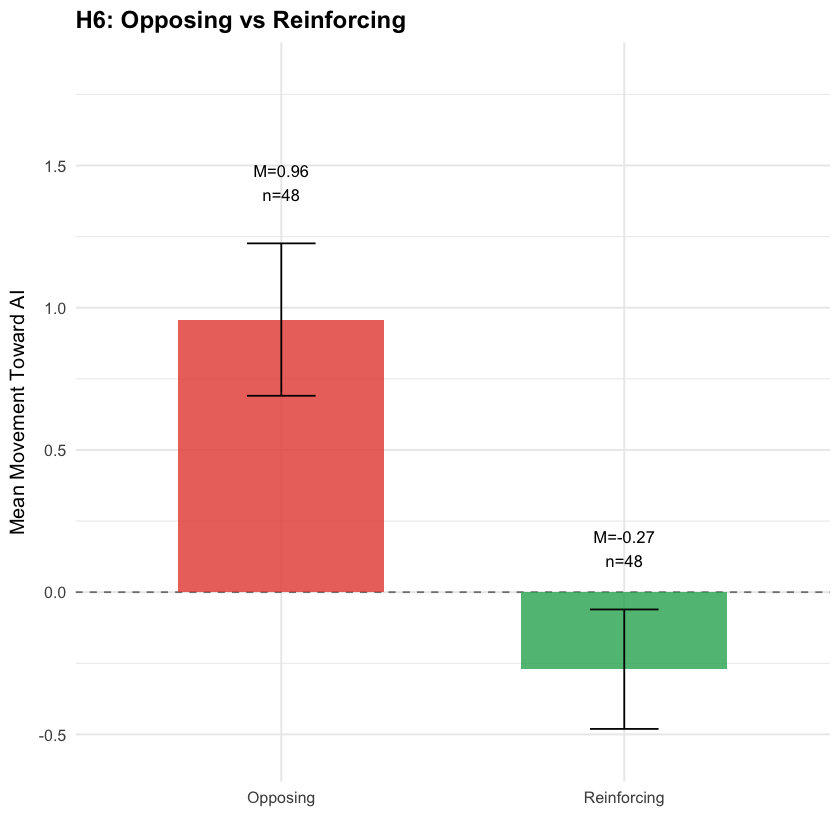


Saved: figures/h6_bar.png and figures/h6_table.png



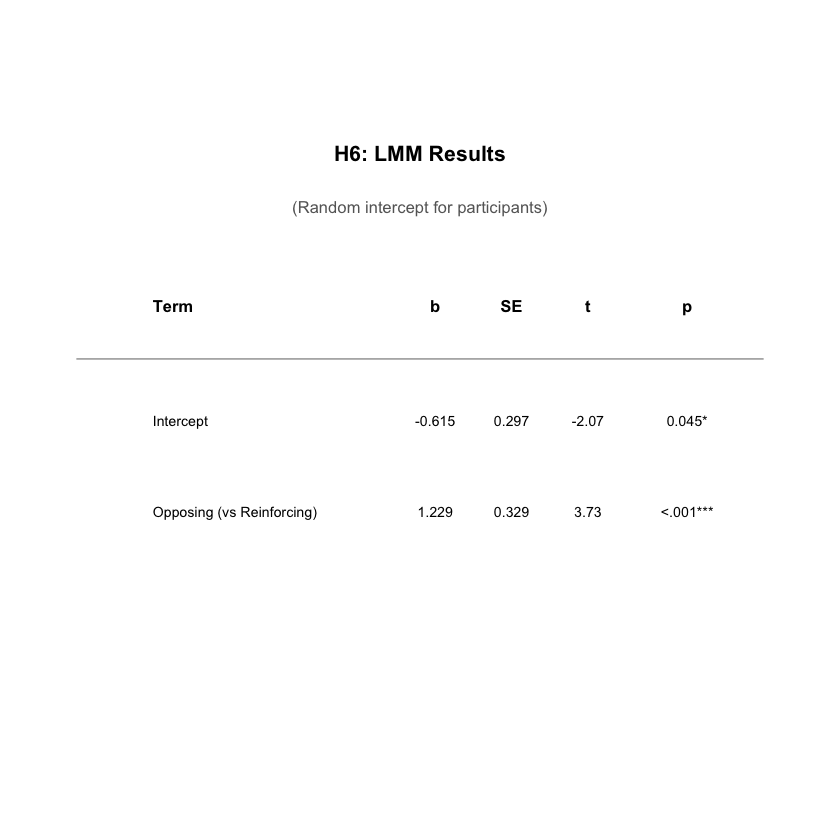

In [18]:
# H6: Opposing vs Reinforcing Stance
message("=== H6: OPPOSING VS REINFORCING STANCE ===\n")

h6_data <- mixed_data

message(sprintf("Full sample: n=%d (opposing=%d, reinforcing=%d)",
                nrow(h6_data), sum(h6_data$is_opposing), sum(!h6_data$is_opposing)))

# Stance was blocked within participant - every participant received exactly two
# opposing and two reinforcing conversations - so the participant random
# intercept carries the contrast and the estimate is a clean within-participant
# comparison.  condition and is_claude are randomised causes of the outcome,
# added for precision only.
lmm_h6       <- lmer(movement_toward_ai ~ is_opposing + condition + is_claude +
                       (1 | participant_id), data = h6_data)
lmm_h6_unadj <- lmer(movement_toward_ai ~ is_opposing +
                       (1 | participant_id), data = h6_data)

message("\n--- Adjusted ---")
print(round(summary(lmm_h6)$coefficients, 3))
message("\n--- Unadjusted ---")
print(round(summary(lmm_h6_unadj)$coefficients, 3))

# Two rows for the summary figure below
coef_h6 <- summary(lmm_h6)$coefficients[c("(Intercept)", "is_opposing"), , drop = FALSE]

# Summary stats for plot
h6_stats <- h6_data %>%
  group_by(stance_mode) %>%
  summarise(n = n(), mean_mov = mean(movement_toward_ai), 
            se_mov = sd(movement_toward_ai) / sqrt(n()), .groups = "drop") %>%
  mutate(condition = ifelse(stance_mode == "opposite", "Opposing", "Reinforcing"),
         label_y = mean_mov + se_mov + 0.15)

# Bar chart
p_h6_bar <- ggplot(h6_stats, aes(x = condition, y = mean_mov, fill = condition)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_mov - se_mov, ymax = mean_mov + se_mov), width = 0.2) +
  geom_text(aes(y = label_y, label = sprintf("M=%.2f\nn=%d", mean_mov, n)), vjust = 0, size = 3.5) +
  scale_fill_manual(values = c("Opposing" = "#E74C3C", "Reinforcing" = "#27AE60")) +
  scale_y_continuous(expand = expansion(mult = c(0.1, 0.3))) +
  labs(title = "H6: Opposing vs Reinforcing", x = "", y = "Mean Movement Toward AI") +
  theme_minimal(base_size = 12) + theme(legend.position = "none", plot.title = element_text(face = "bold"))

print(p_h6_bar)
ggsave("figures/h6_bar.png", p_h6_bar, width = 6, height = 5, dpi = 150)

# Table
term_names <- rownames(coef_h6)
term_names <- gsub("is_opposing", "Opposing (vs Reinforcing)", term_names)
term_names <- gsub("\\(Intercept\\)", "Intercept", term_names)

lmm_tidy <- data.frame(Term = term_names, b = round(coef_h6[, 1], 3),
  SE = round(coef_h6[, 2], 3), t = round(coef_h6[, 4], 2), p = coef_h6[, 5]) %>%
  mutate(p_fmt = ifelse(p < 0.001, "<.001", sprintf("%.3f", p)),
         Sig = case_when(p < 0.001 ~ "***", p < 0.01 ~ "**", p < 0.05 ~ "*", p < 0.1 ~ "†", TRUE ~ ""))

p_h6_table <- ggplot() + theme_void() + xlim(0, 1) + ylim(0, 1) +
  annotate("text", x = 0.5, y = 0.85, label = "H6: LMM Results", size = 4.5, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.78, label = "(Random intercept for participants)", size = 3.5, color = "gray40") +
  annotate("text", x = 0.15, y = 0.65, label = "Term", size = 3.5, fontface = "bold", hjust = 0) +
  annotate("text", x = 0.52, y = 0.65, label = "b", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.62, y = 0.65, label = "SE", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.72, y = 0.65, label = "t", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.85, y = 0.65, label = "p", size = 3.5, fontface = "bold") +
  annotate("segment", x = 0.05, xend = 0.95, y = 0.58, yend = 0.58, color = "gray70")

for (j in 1:nrow(lmm_tidy)) {
  y_pos <- 0.50 - (j-1) * 0.12
  p_h6_table <- p_h6_table +
    annotate("text", x = 0.15, y = y_pos, label = lmm_tidy$Term[j], size = 3, hjust = 0) +
    annotate("text", x = 0.52, y = y_pos, label = lmm_tidy$b[j], size = 3) +
    annotate("text", x = 0.62, y = y_pos, label = lmm_tidy$SE[j], size = 3) +
    annotate("text", x = 0.72, y = y_pos, label = lmm_tidy$t[j], size = 3) +
    annotate("text", x = 0.85, y = y_pos, label = paste0(lmm_tidy$p_fmt[j], lmm_tidy$Sig[j]), size = 3)
}

print(p_h6_table)
ggsave("figures/h6_table.png", p_h6_table, width = 6, height = 4, dpi = 150, bg = "white")
message("\nSaved: figures/h6_bar.png and figures/h6_table.png")

=== ADJUSTED (DAG-specified) ===



# A tibble: 6 × 5
  hypothesis                        estimate std.error statistic p.value
  <fct>                                <dbl>     <dbl>     <dbl>   <dbl>
1 H1: Persuasion vs Control            0.417     0.423     0.985   0.337
2 H2: Personalized vs Persuade        -0.204     0.512    -0.398   0.695
3 H3: Info vs Demo                    -0.052     0.479    -0.109   0.915
4 H4: Extremity (within) x Opposing    0.233     0.375     0.621   0.536
5 H5: Discussed vs Undiscussed         0.362     0.159     2.28    0.024
6 H6: Opposing vs Reinforcing          1.23      0.329     3.73    0    



=== UNADJUSTED, side by side ===



# A tibble: 6 × 5
  hypothesis                         b_adj se_adj b_unadj se_unadj
  <chr>                              <dbl>  <dbl>   <dbl>    <dbl>
1 H1: Persuasion vs Control          0.417  0.423   0.351    0.459
2 H2: Personalized vs Persuade      -0.204  0.512  -0.005    0.547
3 H3: Info vs Demo                  -0.052  0.479  -0.052    0.52 
4 H4: Extremity (within) x Opposing  0.233  0.375  -0.038    0.174
5 H5: Discussed vs Undiscussed       0.362  0.159   0.333    0.168
6 H6: Opposing vs Reinforcing        1.23   0.329   1.23     0.329


Saved: figures/lme_forest_plot.png



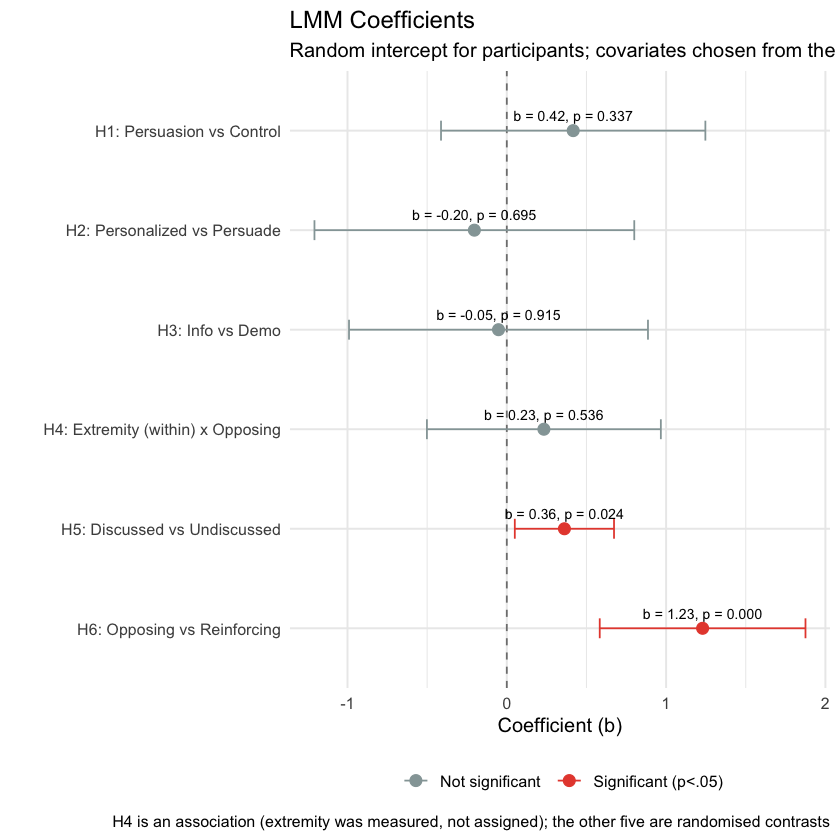

In [19]:
# =============================================================================
# Hypothesis results table - the single source of truth for H1-H6.
# -----------------------------------------------------------------------------
# All six estimates now come from the DAG-specified models:
#   H1, H2, H3   lmm_hyp  (one model, nested contrasts, all 24 participants)
#   H4           lmm_h4   (within-participant extremity, by AI stance)
#   H5           lmm_h5   (all 192 ratings; the paired t-test is kept as a
#                          descriptive companion in the H5 cell)
#   H6           lmm_h6   (stance, blocked within participant)
#
# TABLE 2 FALLACY (Westreich & Greenland).  In a typical regression only the
# exposure coefficient carries a causal reading.  This study is the unusual case
# where FOUR do - condition, provider, stance and had_chat are each
# independently randomised or blocked - so each hypothesis row below is causal
# in its own model.  extremity is the exception: it was measured, not assigned,
# so H4 is reported as the within-participant association.
#
# Every row is shown adjusted AND unadjusted.  Under randomisation the two
# should agree; the gap is noise, not deconfounding.
# =============================================================================

pull_term <- function(model, term, label, causal = TRUE) {
  co <- summary(model)$coefficients
  if (!term %in% rownames(co)) return(NULL)
  tibble(
    hypothesis = label,
    term       = term,
    estimate   = co[term, 1],
    std.error  = co[term, 2],
    statistic  = co[term, 4],
    p.value    = co[term, 5],
    conf.low   = co[term, 1] - 1.96 * co[term, 2],
    conf.high  = co[term, 1] + 1.96 * co[term, 2],
    causal     = causal
  )
}

hyp_levels <- c("H1: Persuasion vs Control",
                "H2: Personalized vs Persuade",
                "H3: Info vs Demo",
                "H4: Extremity (within) x Opposing",
                "H5: Discussed vs Undiscussed",
                "H6: Opposing vs Reinforcing")

lme_results <- bind_rows(
  pull_term(lmm_hyp, "conditionC1_persuasion", hyp_levels[1]),
  pull_term(lmm_hyp, "conditionC2_personal",   hyp_levels[2]),
  pull_term(lmm_hyp, "conditionC3_info",       hyp_levels[3]),
  pull_term(lmm_h4,  "is_opposing:extremity_w", hyp_levels[4], causal = FALSE),
  pull_term(lmm_h5,  "had_chatTRUE",           hyp_levels[5]),
  pull_term(lmm_h6,  "is_opposing",            hyp_levels[6])
) %>%
  mutate(hypothesis  = factor(hypothesis, levels = rev(hyp_levels)),
         significant = p.value < 0.05)

lme_results_unadj <- bind_rows(
  pull_term(lmm_hyp_unadj, "conditionC1_persuasion", hyp_levels[1]),
  pull_term(lmm_hyp_unadj, "conditionC2_personal",   hyp_levels[2]),
  pull_term(lmm_hyp_unadj, "conditionC3_info",       hyp_levels[3]),
  pull_term(lmm_h4_unadj,  "extremity",              hyp_levels[4], causal = FALSE),
  pull_term(lmm_h5_unadj,  "had_chatTRUE",           hyp_levels[5]),
  pull_term(lmm_h6_unadj,  "is_opposing",            hyp_levels[6])
)

message("=== ADJUSTED (DAG-specified) ===")
print(lme_results %>%
        dplyr::select(hypothesis, estimate, std.error, statistic, p.value) %>%
        mutate(across(where(is.numeric), ~round(.x, 3))))

# The H4 row compares unlike terms by necessity: the adjusted column is the
# extremity x stance interaction, the unadjusted column is the single pooled
# extremity slope that the interaction replaces.  Read that row as "what the
# pooled specification reports" rather than as an adjusted/unadjusted contrast.
message("\n=== UNADJUSTED, side by side ===")
print(lme_results %>%
        dplyr::select(hypothesis, b_adj = estimate, se_adj = std.error) %>%
        left_join(lme_results_unadj %>%
                    dplyr::select(hypothesis, b_unadj = estimate,
                                  se_unadj = std.error),
                  by = "hypothesis") %>%
        mutate(across(where(is.numeric), ~round(.x, 3))))

# Forest plot
p_forest <- ggplot(lme_results, aes(x = estimate, y = hypothesis, color = significant)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(size = 3) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.2) +
  geom_text(aes(label = sprintf("b = %.2f, p = %.3f", estimate, p.value)), 
            vjust = -1, size = 3, color = "black") +
  scale_color_manual(values = c("FALSE" = "#95A5A6", "TRUE" = "#E74C3C"),
                     labels = c("Not significant", "Significant (p<.05)")) +
  labs(title = "LMM Coefficients",
       subtitle = "Random intercept for participants; covariates chosen from the design DAG",
       x = "Coefficient (b)", y = "", color = "",
       caption = "H4 is an association (extremity was measured, not assigned); the other five are randomised contrasts") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p_forest)
ggsave("figures/lme_forest_plot.png", p_forest, width = 8, height = 5, dpi = 150)
message("Saved: figures/lme_forest_plot.png")

=== LMM SUMMARY TABLES ===



LMM Results Summary (all six from the DAG-specified models):



# A tibble: 6 × 6
  Hypothesis                             b    SE     t p_formatted Sig  
  <chr>                              <dbl> <dbl> <dbl> <chr>       <chr>
1 H1: Persuasion vs Control          0.417 0.423  0.98 0.337       ""   
2 H2: Personalized vs Persuade      -0.204 0.512 -0.4  0.695       ""   
3 H3: Info vs Demo                  -0.052 0.479 -0.11 0.915       ""   
4 H4: Extremity (within) x Opposing  0.233 0.375  0.62 0.536       ""   
5 H5: Discussed vs Undiscussed       0.362 0.159  2.28 0.024       "*"  
6 H6: Opposing vs Reinforcing        1.23  0.329  3.73 <.001       "***"



Saved: figures/lmm_summary_table.png



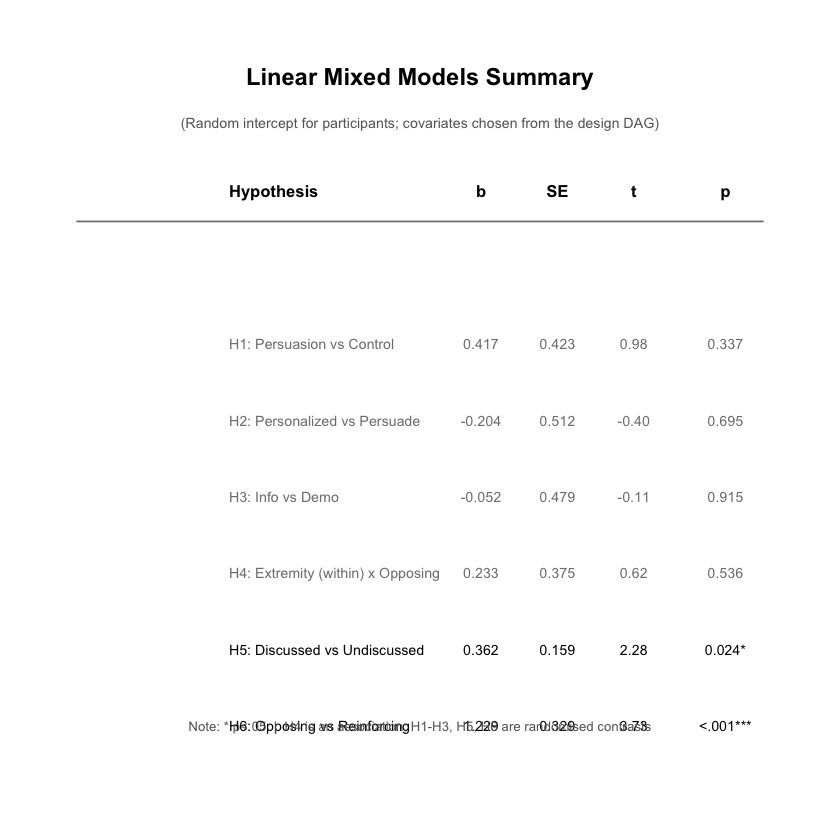

In [20]:
# =============================================================================
# LMM Summary Table
# =============================================================================

message("=== LMM SUMMARY TABLES ===\n")

lmm_summary <- lme_results %>%
  arrange(factor(hypothesis, levels = hyp_levels)) %>%
  transmute(
    Hypothesis = as.character(hypothesis),
    b  = round(estimate, 3),
    SE = round(std.error, 3),
    t  = round(statistic, 2),
    p  = p.value,
    p_formatted = ifelse(p < 0.001, "<.001", sprintf("%.3f", p)),
    Sig = case_when(
      p < 0.001 ~ "***",
      p < 0.01  ~ "**",
      p < 0.05  ~ "*",
      p < 0.1   ~ "†",
      TRUE      ~ ""
    )
  )

message("\nLMM Results Summary (all six from the DAG-specified models):")
print(lmm_summary %>% dplyr::select(Hypothesis, b, SE, t, p_formatted, Sig))

# Create table visualization
p_table <- ggplot() +
  theme_void() +
  xlim(0, 1) + ylim(0, 1) +
  annotate("text", x = 0.5, y = 0.95, label = "Linear Mixed Models Summary", 
           size = 5, fontface = "bold") +
  annotate("text", x = 0.5, y = 0.89, label = "(Random intercept for participants; covariates chosen from the design DAG)", 
           size = 3, color = "gray40") +
  annotate("text", x = 0.25, y = 0.80, label = "Hypothesis", size = 3.5, fontface = "bold", hjust = 0) +
  annotate("text", x = 0.58, y = 0.80, label = "b", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.68, y = 0.80, label = "SE", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.78, y = 0.80, label = "t", size = 3.5, fontface = "bold") +
  annotate("text", x = 0.90, y = 0.80, label = "p", size = 3.5, fontface = "bold") +
  annotate("segment", x = 0.05, xend = 0.95, y = 0.76, yend = 0.76, color = "gray50")

for (j in 1:nrow(lmm_summary)) {
  y_pos <- 0.70 - (j * 0.10)
  row_color <- ifelse(lmm_summary$p[j] < 0.05, "black", "gray50")
  p_table <- p_table +
    annotate("text", x = 0.25, y = y_pos, label = lmm_summary$Hypothesis[j], 
             size = 3, hjust = 0, color = row_color) +
    annotate("text", x = 0.58, y = y_pos, label = sprintf("%.3f", lmm_summary$b[j]), 
             size = 3, color = row_color) +
    annotate("text", x = 0.68, y = y_pos, label = sprintf("%.3f", lmm_summary$SE[j]), 
             size = 3, color = row_color) +
    annotate("text", x = 0.78, y = y_pos, label = sprintf("%.2f", lmm_summary$t[j]), 
             size = 3, color = row_color) +
    annotate("text", x = 0.90, y = y_pos, label = paste0(lmm_summary$p_formatted[j], lmm_summary$Sig[j]), 
             size = 3, color = row_color)
}

p_table <- p_table +
  annotate("text", x = 0.5, y = 0.10, 
           label = "Note: * p<.05  |  H4 is an association; H1-H3, H5, H6 are randomised contrasts", 
           size = 2.8, color = "gray40")

print(p_table)
ggsave("figures/lmm_summary_table.png", p_table, width = 10, height = 5, dpi = 300, bg = "white")
message("\nSaved: figures/lmm_summary_table.png")

=== ADDITIONAL FINDINGS: LLM & FRAMEWORK EFFECTS ===


Data: 79 observations (excluding ceiling/floor)


--- Full LMM ---



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: movement_toward_ai ~ is_claude + is_opposing + condition + (1 |  
    participant_id)
   Data: additional_data

REML criterion at convergence: 310.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.37416 -0.59046 -0.07718  0.45700  2.58817 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.2799   0.5291  
 Residual                   3.0376   1.7429  
Number of obs: 79, groups:  participant_id, 24

Fixed effects:
                       Estimate Std. Error       df t value Pr(>|t|)   
(Intercept)            -0.82542    0.39354 38.19826  -2.097  0.04263 * 
is_claude               1.00763    0.46364 18.72709   2.173  0.04280 * 
is_opposing             1.35135    0.40457 58.30978   3.340  0.00146 **
conditionC1_persuasion  0.40128    0.52081 17.33436   0.771  0.45138   
conditionC2_personal   -0.35922    0.63139 17.31967  -0.569  0.576


All Coefficients:



                                        label   estimate        se           p
is_claude                    Claude (vs Qwen)  1.0076275 0.4636421 0.042804367
is_opposing                   Opposing Stance  1.3513530 0.4045735 0.001464443
conditionC1_persuasion conditionC1_persuasion  0.4012840 0.5208089 0.451376923
conditionC2_personal     conditionC2_personal -0.3592207 0.6313918 0.576704560
conditionC3_info             conditionC3_info  0.0121517 0.5999329 0.984059265
                       significant
is_claude                     TRUE
is_opposing                   TRUE
conditionC1_persuasion       FALSE
conditionC2_personal         FALSE
conditionC3_info             FALSE



Saved: figures/additional_findings.png


--- % Moved Toward AI by LLM × Framework ---



# A tibble: 4 × 4
  llm_label framework_label     n pct_toward
  <chr>     <chr>           <int>      <dbl>
1 Claude    Deontological      10       70  
2 Claude    Utilitarian        11       90.9
3 Qwen      Deontological      15       53.3
4 Qwen      Utilitarian         7       42.9


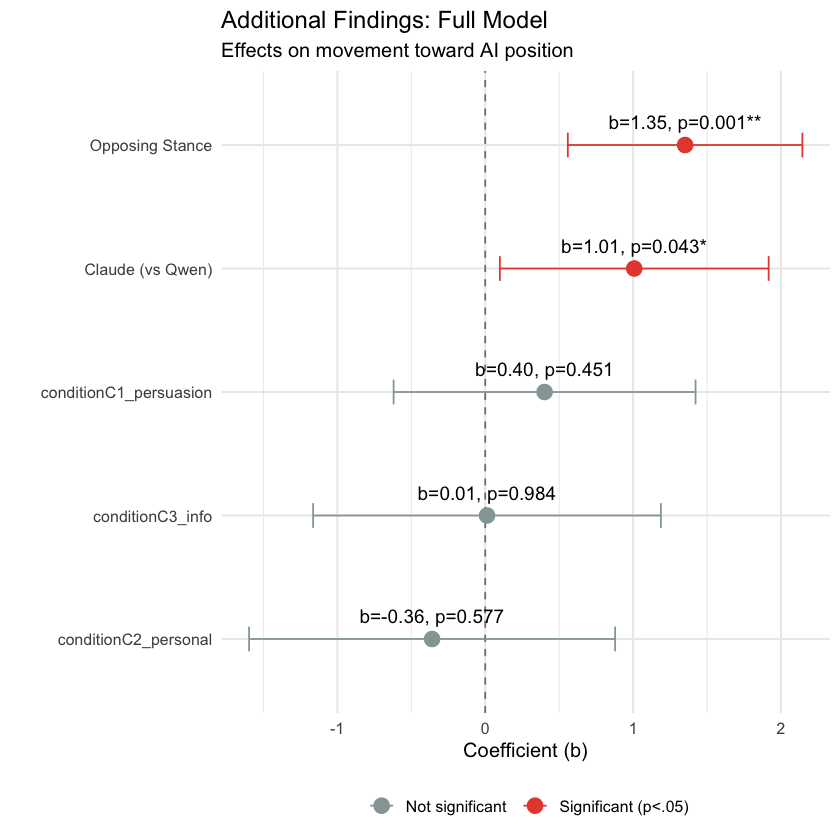

Saved: figures/llm_framework_interaction.png



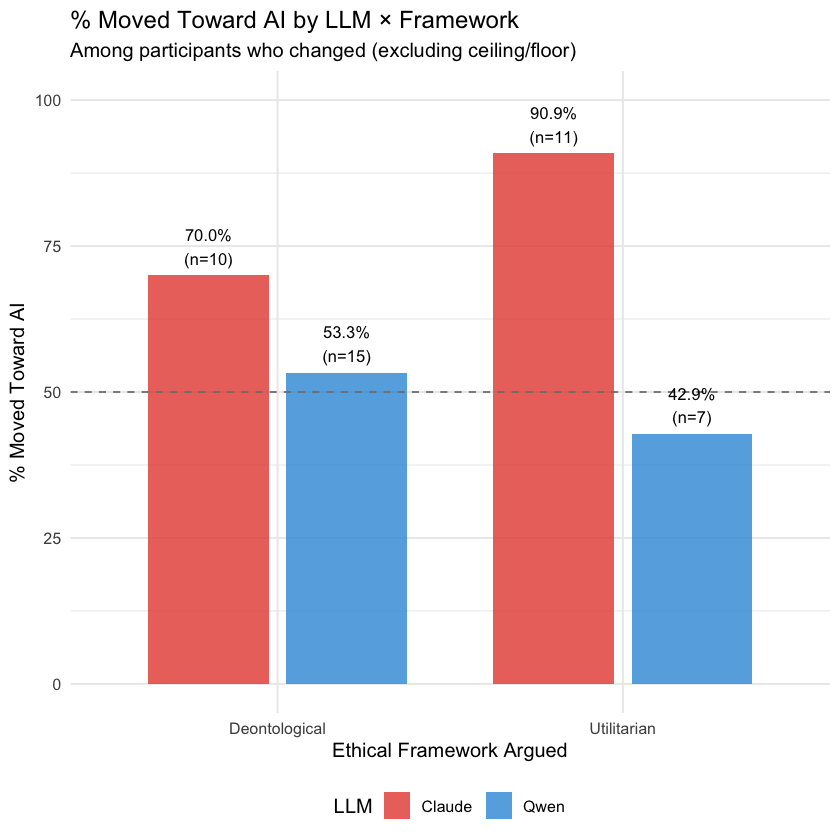

In [21]:
# =============================================================================
# Additional Findings: LLM Provider and Framework Effects
# =============================================================================

message("=== ADDITIONAL FINDINGS: LLM & FRAMEWORK EFFECTS ===\n")

# SENSITIVITY ANALYSIS.  Reinforcing conversations that started at 1 or 7 have
# no room left to move toward the AI, so this cell drops them and refits.  This
# is a bounded-scale exclusion, not a control-selection decision: the DAG is
# unchanged, only the sample is.
#
# Derived from mixed_data rather than rebuilt from data_chat_analysis, so the
# C1/C2/C3 condition contrasts and the derived variables carry through.
additional_data <- mixed_data %>%
  filter(
    stance_mode == "opposite" |
    (stance_mode == "same" & !rating_pre %in% c(1, 7))
  )
contrasts(additional_data$condition) <- cond_contrasts

message(sprintf("Data: %d observations (excluding ceiling/floor)", nrow(additional_data)))

# is_claude * is_utilitarian removed: is_utilitarian is a collider on
# stance_mode and rating_pre (see the covariate-ladder cell).
lmm_additional <- lmer(movement_toward_ai ~ is_claude + is_opposing + condition +
                       (1 | participant_id), data = additional_data)

message("\n--- Full LMM ---")
summary(lmm_additional)

# Extract all coefficients (except intercept)
coefs <- summary(lmm_additional)$coefficients
coef_df <- data.frame(
  term = rownames(coefs),
  estimate = coefs[, 1],
  se = coefs[, 2],
  p = coefs[, 5]
) %>%
  filter(term != "(Intercept)") %>%
  mutate(
    conf.low = estimate - 1.96 * se,
    conf.high = estimate + 1.96 * se,
    significant = p < 0.05,
    label = case_when(
      term == "is_claude" ~ "Claude (vs Qwen)",
  
      term == "is_opposing" ~ "Opposing Stance",
  
      TRUE ~ term
    )
  )

message("\nAll Coefficients:")
print(coef_df %>% select(label, estimate, se, p, significant))

# Forest plot showing all effects
p_additional <- ggplot(coef_df, aes(x = estimate, y = reorder(label, estimate), 
                                     color = significant)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(size = 4) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.2) +
  geom_text(aes(label = sprintf("b=%.2f, p=%.3f%s", estimate, p, 
                                ifelse(p < 0.001, "***", 
                                ifelse(p < 0.01, "**",
                                ifelse(p < 0.05, "*",
                                ifelse(p < 0.1, "†", "")))))), 
            vjust = -1.2, size = 4, color = "black") +
  scale_color_manual(values = c("FALSE" = "#95A5A6", "TRUE" = "#E74C3C"),
                     labels = c("Not significant", "Significant (p<.05)")) +
  labs(title = "Additional Findings: Full Model",
       subtitle = "Effects on movement toward AI position",
       x = "Coefficient (b)", y = "", color = "") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p_additional)
ggsave("figures/additional_findings.png", p_additional, width = 8, height = 5, dpi = 150)
message("\nSaved: figures/additional_findings.png")

# Grouped bar chart: % moved toward AI by LLM × Framework
message("\n--- % Moved Toward AI by LLM × Framework ---")

changers <- additional_data %>% filter(outcome %in% c("Moved toward AI", "Backfired"))

llm_framework_stats <- changers %>%
  mutate(
    llm_label = ifelse(llm_provider == "anthropic", "Claude", "Qwen"),
    framework_label = ifelse(llm_framework == "utilitarian", "Utilitarian", "Deontological")
  ) %>%
  group_by(llm_label, framework_label) %>%
  summarise(
    n = n(),
    pct_toward = mean(outcome == "Moved toward AI") * 100,
    .groups = "drop"
  )

print(llm_framework_stats)

p_llm_framework <- ggplot(llm_framework_stats, 
                          aes(x = framework_label, y = pct_toward, fill = llm_label)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7, alpha = 0.8) +
  geom_hline(yintercept = 50, linetype = "dashed", color = "gray50") +
  geom_text(aes(label = sprintf("%.1f%%\n(n=%d)", pct_toward, n)),
            position = position_dodge(width = 0.8), vjust = -0.3, size = 3.5) +
  scale_fill_manual(values = c("Claude" = "#E74C3C", "Qwen" = "#3498DB")) +
  scale_y_continuous(limits = c(0, 100), breaks = seq(0, 100, 25)) +
  labs(title = "% Moved Toward AI by LLM × Framework",
       subtitle = "Among participants who changed (excluding ceiling/floor)",
       x = "Ethical Framework Argued", y = "% Moved Toward AI", fill = "LLM") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p_llm_framework)
ggsave("figures/llm_framework_interaction.png", p_llm_framework, width = 8, height = 5, dpi = 150)
message("Saved: figures/llm_framework_interaction.png")


=== DEBRIEF VARIABLES (DESCRIPTIVE ONLY - descendants of the outcome) ===


Data: 79 observations

AI Trust: M=5.17, SD=1.27

Noticed Persuasion: 78% yes

Perceived Change: 47% yes


--- MODEL 1: AI Trust ---

AI Trust effect: b=0.184, SE=0.180, t=1.02, p=0.3169 


--- MODEL 2: Noticed Persuasion ---

Noticed Persuasion effect: b=-0.029, SE=0.574, t=-0.05, p=0.9597 


--- MODEL 3: Perceived Change ---

Perceived Change effect: b=0.860, SE=0.433, t=1.99, p=0.0607 †


--- MODEL 4: Full Debrief Model ---



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
movement_toward_ai ~ ai_trust_c + noticed_persuasion + perceived_change +  
    is_opposing + (1 | participant_id)
   Data: debrief_data

REML criterion at convergence: 314

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.79835 -0.61269 -0.01963  0.59609  2.15517 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.2484   0.4984  
 Residual                   3.0246   1.7391  
Number of obs: 79, groups:  participant_id, 24

Fixed effects:
                   Estimate Std. Error       df t value Pr(>|t|)   
(Intercept)        -0.38587    0.53655 25.79434  -0.719   0.4785   
ai_trust_c          0.06018    0.18345 23.06493   0.328   0.7458   
noticed_persuasion -0.67832    0.62383 18.22390  -1.087   0.2911   
perceived_change    1.08675    0.53743 19.40287   2.022   0.0572 . 
is_opposing         1.38517    0.40351 58.59138   3.433   0.0


Debrief Variable Effects (controlling for stance):



                                label    estimate        se          p
ai_trust_c                   AI Trust  0.06018188 0.1834487 0.74582696
noticed_persuasion Noticed Persuasion -0.67832292 0.6238330 0.29105622
perceived_change     Perceived Change  1.08675020 0.5374303 0.05717033
                   significant
ai_trust_c               FALSE
noticed_persuasion       FALSE
perceived_change         FALSE



Saved: figures/debrief_effects.png



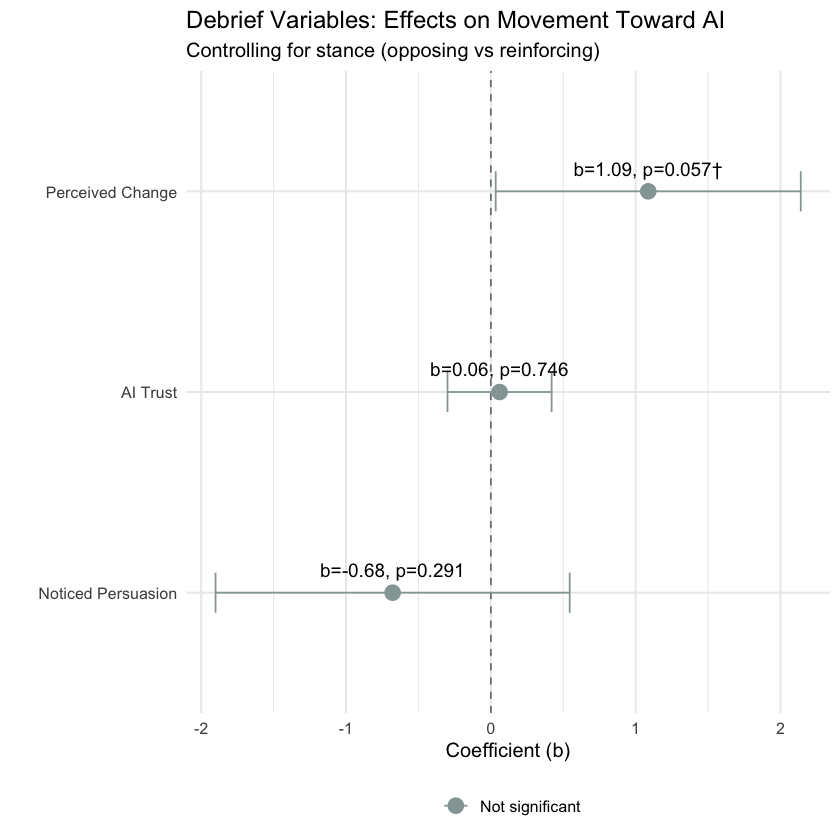

In [22]:
# =============================================================================
# Debrief variables: AI Trust, Noticed Persuasion, Perceived Change
# -----------------------------------------------------------------------------
# *** THESE ARE DESCRIPTIVE ASSOCIATIONS, NOT CAUSAL ESTIMATES. ***
#
# All three are measured at debrief, AFTER the conversations, and all three ask
# about the AI assistant the participant just argued with.  In the design DAG
# they are DESCENDANTS OF THE OUTCOME, not causes of it:
#
#     movement -> noticed_persuasion
#     movement -> changed_mind
#     movement -> stias (trust)
#
# Regressing movement on a descendant of movement is the textbook bad control in
# Cinelli, Forney & Pearl - it induces bias in an otherwise unbiased estimate.
# The coefficients below are reported as correlations between what participants
# did and what they later said about it, and must NOT be read as "trust caused
# movement" or "noticing reduced movement".  Do not add these terms to any of
# the hypothesis models above.
#
# They also cannot serve as manipulation checks for the same reason: a
# manipulation check has to be independent of the outcome.
# =============================================================================

message("=== DEBRIEF VARIABLES (DESCRIPTIVE ONLY - descendants of the outcome) ===\n")

# Prepare data - columns already in data_chat_analysis
debrief_data <- data_chat_analysis %>%
  filter(
    stance_mode == "opposite" |
    (stance_mode == "same" & !rating_pre %in% c(1, 7))
  ) %>%
  mutate(
    movement_toward_ai = case_when(
      outcome == "Moved toward AI" ~ abs(rating_change),
      outcome == "Backfired" ~ -abs(rating_change),
      TRUE ~ 0
    ),
    is_opposing = ifelse(stance_mode == "opposite", 1, 0),
    # Center AI trust for interpretation
    ai_trust_c = scale(debrief_stias_average, center = TRUE, scale = FALSE)[,1],
    noticed_persuasion = ifelse(debrief_noticed_persuasion == TRUE, 1, 0),
    perceived_change = ifelse(debrief_changed_mind == TRUE, 1, 0),
    participant_id = factor(participant_id)
  )

message(sprintf("Data: %d observations", nrow(debrief_data)))
message(sprintf("AI Trust: M=%.2f, SD=%.2f", 
                mean(debrief_data$debrief_stias_average, na.rm=TRUE),
                sd(debrief_data$debrief_stias_average, na.rm=TRUE)))
message(sprintf("Noticed Persuasion: %d%% yes", 
                round(mean(debrief_data$noticed_persuasion, na.rm=TRUE) * 100)))
message(sprintf("Perceived Change: %d%% yes", 
                round(mean(debrief_data$perceived_change, na.rm=TRUE) * 100)))

# -----------------------------------------------------------------------------
# Model 1: AI Trust predicting movement toward AI
# -----------------------------------------------------------------------------
message("\n--- MODEL 1: AI Trust ---")
lmm_trust <- lmer(movement_toward_ai ~ ai_trust_c + is_opposing + 
                  (1 | participant_id), data = debrief_data)
coef_trust <- summary(lmm_trust)$coefficients["ai_trust_c", ]
message(sprintf("AI Trust effect: b=%.3f, SE=%.3f, t=%.2f, p=%.4f %s",
                coef_trust[1], coef_trust[2], coef_trust[4], coef_trust[5],
                ifelse(coef_trust[5] < 0.05, "*", ifelse(coef_trust[5] < 0.1, "†", ""))))

# -----------------------------------------------------------------------------
# Model 2: Noticed Persuasion predicting movement
# -----------------------------------------------------------------------------
message("\n--- MODEL 2: Noticed Persuasion ---")
lmm_noticed <- lmer(movement_toward_ai ~ noticed_persuasion + is_opposing + 
                    (1 | participant_id), data = debrief_data)
coef_noticed <- summary(lmm_noticed)$coefficients["noticed_persuasion", ]
message(sprintf("Noticed Persuasion effect: b=%.3f, SE=%.3f, t=%.2f, p=%.4f %s",
                coef_noticed[1], coef_noticed[2], coef_noticed[4], coef_noticed[5],
                ifelse(coef_noticed[5] < 0.05, "*", ifelse(coef_noticed[5] < 0.1, "†", ""))))

# -----------------------------------------------------------------------------
# Model 3: Perceived Change predicting movement
# -----------------------------------------------------------------------------
message("\n--- MODEL 3: Perceived Change ---")
lmm_perceived <- lmer(movement_toward_ai ~ perceived_change + is_opposing + 
                      (1 | participant_id), data = debrief_data)
coef_perceived <- summary(lmm_perceived)$coefficients["perceived_change", ]
message(sprintf("Perceived Change effect: b=%.3f, SE=%.3f, t=%.2f, p=%.4f %s",
                coef_perceived[1], coef_perceived[2], coef_perceived[4], coef_perceived[5],
                ifelse(coef_perceived[5] < 0.05, "*", ifelse(coef_perceived[5] < 0.1, "†", ""))))

# -----------------------------------------------------------------------------
# Model 4: Full model with all debrief variables
# -----------------------------------------------------------------------------
message("\n--- MODEL 4: Full Debrief Model ---")
lmm_full_debrief <- lmer(movement_toward_ai ~ ai_trust_c + noticed_persuasion + 
                         perceived_change + is_opposing + 
                         (1 | participant_id), data = debrief_data)
summary(lmm_full_debrief)

# -----------------------------------------------------------------------------
# Visualization: Forest plot of debrief effects
# -----------------------------------------------------------------------------
coefs <- summary(lmm_full_debrief)$coefficients
debrief_coef_df <- data.frame(
  term = rownames(coefs),
  estimate = coefs[, 1],
  se = coefs[, 2],
  p = coefs[, 5]
) %>%
  filter(term != "(Intercept)" & term != "is_opposing") %>%
  mutate(
    conf.low = estimate - 1.96 * se,
    conf.high = estimate + 1.96 * se,
    significant = p < 0.05,
    label = case_when(
      term == "ai_trust_c" ~ "AI Trust",
      term == "noticed_persuasion" ~ "Noticed Persuasion",
      term == "perceived_change" ~ "Perceived Change",
      TRUE ~ term
    )
  )

message("\nDebrief Variable Effects (controlling for stance):")
print(debrief_coef_df %>% select(label, estimate, se, p, significant))

p_debrief <- ggplot(debrief_coef_df, aes(x = estimate, y = reorder(label, estimate), 
                                          color = significant)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(size = 4) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.2) +
  geom_text(aes(label = sprintf("b=%.2f, p=%.3f%s", estimate, p, 
                                ifelse(p < 0.001, "***", 
                                ifelse(p < 0.01, "**",
                                ifelse(p < 0.05, "*",
                                ifelse(p < 0.1, "†", "")))))), 
            vjust = -1.2, size = 4, color = "black") +
  scale_color_manual(values = c("FALSE" = "#95A5A6", "TRUE" = "#E74C3C"),
                     labels = c("Not significant", "Significant (p<.05)")) +
  labs(title = "Debrief Variables: Effects on Movement Toward AI",
       subtitle = "Controlling for stance (opposing vs reinforcing)",
       x = "Coefficient (b)", y = "", color = "") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")

print(p_debrief)
ggsave("figures/debrief_effects.png", p_debrief, width = 8, height = 4, dpi = 150)
message("\nSaved: figures/debrief_effects.png")


## Summary: Hypothesis Test Results

=== QUALITATIVE FINDINGS: THEMATIC CODING ===


--- Individual Coding: Why Changed ---



# A tibble: 14 × 3
      id theme                code                                        
   <dbl> <chr>                <chr>                                       
 1     1 Deliberation Process Defending position led to more extreme views
 2     2 No Change            No change reported                          
 3     3 Other                Noted AI inconsistency                      
 4     4 New Perspectives     Considered new perspectives                 
 5     5 Compelling Arguments Found AI arguments reasonable               
 6     6 No Change            No change reported                          
 7     7 Deliberation Process Changed how they weighed principles         
 8     8 Compelling Arguments Found AI arguments acceptable               
 9     9 No Change            No change reported                          
10    10 New Perspectives     Realized something they had missed          
11    11 Compelling Arguments AI was persuasive                           
12    


--- Theme Counts: Why Changed ---




Compelling Arguments Deliberation Process     New Perspectives 
                   3                    3                    4 
           No Change                Other 
                   3                    1 



--- Individual Coding: Persuasion Tactics ---



# A tibble: 21 × 3
      id theme                   code                               
   <dbl> <chr>                   <chr>                              
 1     1 AI Persistence          Made arguments without being overt 
 2     2 AI Persistence          AI wouldn't budge, kept reinforcing
 3     3 Acknowledge & Counter   Validated then countered           
 4     4 Reinforcement           AI supported their view            
 5     5 AI Persistence          Unwilling to concede               
 6     6 Emotional/Value Appeals Used families, responsibilities    
 7     7 Emotional/Value Appeals Pushed specific ethical framework  
 8     8 AI Persistence          Tried to convince                  
 9     9 None Noticed            No persuasion noticed              
10    10 Acknowledge & Counter   Reflected views back stronger      
# ℹ 11 more rows



--- Theme Counts: Persuasion Tactics ---




  Acknowledge & Counter          AI Persistence Emotional/Value Appeals 
                      3                       7                       3 
           None Noticed                   Other           Reinforcement 
                      3                       3                       2 



Saved: figures/qual_change_themes.png



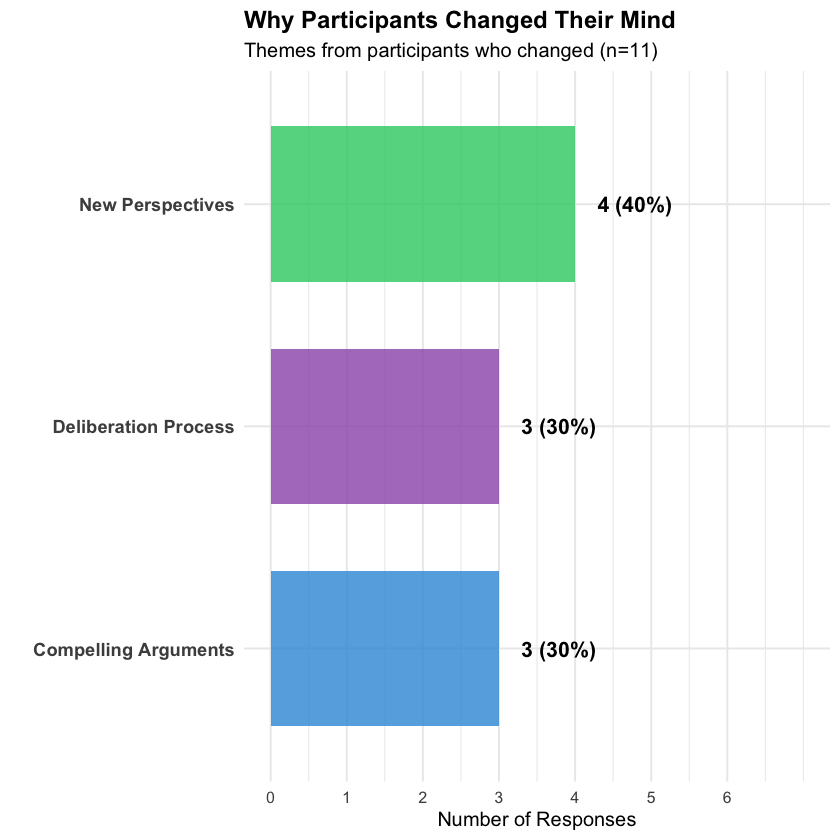

Saved: figures/qual_persuasion_themes.png



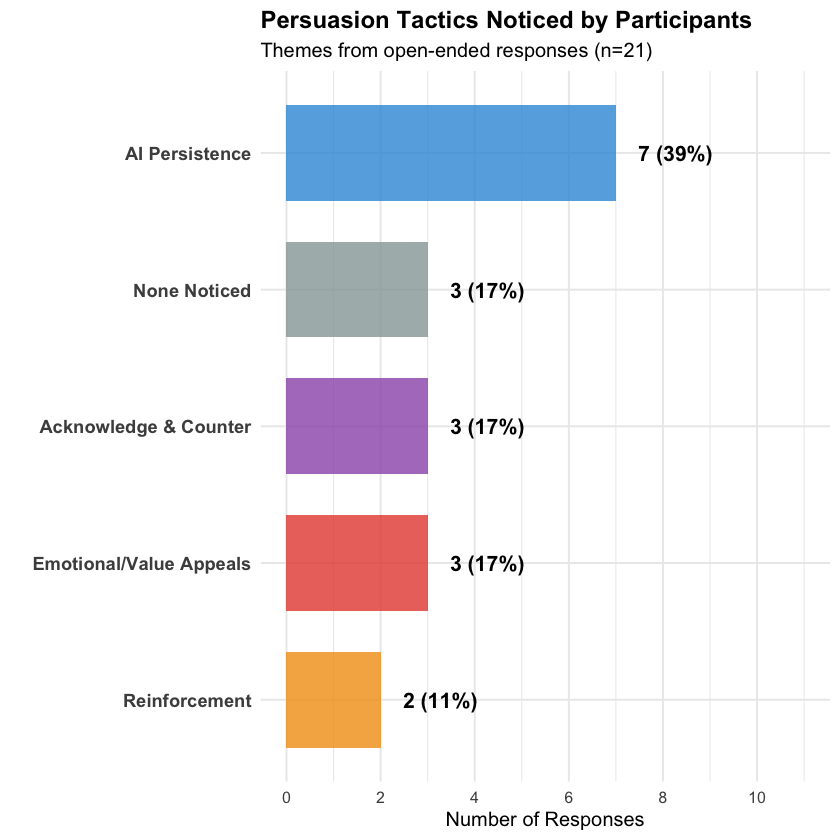

In [23]:
# =============================================================================
# Qualitative Findings: Thematic Analysis
# =============================================================================

message("=== QUALITATIVE FINDINGS: THEMATIC CODING ===\n")

# -----------------------------------------------------------------------------
# CODING: Why Participants Changed Their Mind (debrief_change_description)
# -----------------------------------------------------------------------------

change_coding <- tribble(
  ~id, ~response, ~code, ~theme,
  1, "It didn't make me switch from morally right to morally wrong but after having to defend my points it sometimes led me to the more extreme scale of morality instead of some middle ground.", "Defending position led to more extreme views", "Deliberation Process",
  2, "None of the discussions changed my mind.", "No change reported", "No Change",
  3, "The AI shifted from saying one doesn't have a moral responsibility to kill someone to save others to saying one does (in the last dilemma case).", "Noted AI inconsistency", "Other",
  4, "The discussions did not completely change my opinions, but they made me consider perspectives I had not thought of initially. In a few cases, such as the ransom and the submarine scenarios, I became more open to reconsidering.", "Considered new perspectives", "New Perspectives",
  5, "I saw them understandable and ethically fit", "Found AI arguments reasonable", "Compelling Arguments",
  6, "none", "No change reported", "No Change",
  7, "What changed was less about switching to a completely different moral view and more about how I prioritized the principles in the trade-offs.", "Changed how they weighed principles", "Deliberation Process",
  8, "It was ethically acceptable on what it we discussed on", "Found AI arguments acceptable", "Compelling Arguments",
  9, "No", "No change reported", "No Change",
  10, "The one regarding the tunnel - I failed to realize other lives would be lost.", "Realized something they had missed", "New Perspectives",
  11, "again the guerrilla group was quite persuasive and caused me to re think my assumption", "AI was persuasive", "Compelling Arguments",
  12, "The conversation about the nurse was where my perspective was changed because of the AI. The AI made a good argument that if the nurse hit the switch, she would be directly involved in the death of someone.", "AI made good arguments", "New Perspectives",
  13, "Certain dilemmas e.g the submarine situation and shooting a crew member. The AI bot made me reevaluate my opinion and offered a different perspective/things I didn't thoroughly consider.", "AI offered different perspective", "New Perspectives",
  14, "I changed my mind about paying the ransom for the journalist based on my back and forth with the AI about the different moral considerations of the situation as a whole.", "Back-and-forth deliberation helped", "Deliberation Process"
)

message("--- Individual Coding: Why Changed ---")
print(change_coding %>% select(id, theme, code))

message("\n--- Theme Counts: Why Changed ---")
print(table(change_coding$theme))

# -----------------------------------------------------------------------------
# CODING: Persuasion Tactics Noticed (debrief_persuasion_description)
# -----------------------------------------------------------------------------

persuasion_coding <- tribble(
  ~id, ~response, ~code, ~theme,
  1, "It might not have explicitly tried to persuade me but, it made arguments for its way of thinking which is trying to persuade me in a way.", "Made arguments without being overt", "AI Persistence",
  2, "When the AI stated a different opinion than me at the start of a conversation, it would not budge on its stance at all. Even if I brought up very good points, it just kept reinforcing the same thing over and over.", "AI wouldn't budge, kept reinforcing", "AI Persistence",
  3, "It kept saying that it understood my point of view, but disagreed with it and explained why.", "Validated then countered", "Acknowledge & Counter",
  4, "The AI would argument my point", "AI supported their view", "Reinforcement",
  5, "I could tell when it was opposed, and seemed unwilling to concede to me, rather trying to get me to concede towards its view.", "Unwilling to concede", "AI Persistence",
  6, "The AI often reinforced my initial opinion and focused on arguments that supported my position. In some cases, it used emotional examples or personal perspectives, such as discussing families or responsibilities, to make its point more persuasive.", "Used families, responsibilities", "Emotional/Value Appeals",
  7, "I feel like the AI was trying to change my opinion to value everyone's life the same, regardless of the situation.", "Pushed specific ethical framework", "Emotional/Value Appeals",
  8, "I was disagreeing with the ai opinion and it tried to convince me", "Tried to convince", "AI Persistence",
  9, "none", "No persuasion noticed", "None Noticed",
  10, "Reflected your previous views back at you in a slightly stronger, more unified direction, Framed each dilemma as a forced binary choice between dignity rule vs outcome maximization", "Reflected views back stronger", "Acknowledge & Counter",
  11, "I disagreed with the AI And it persuaded me to on the decision", "Persuasion worked", "AI Persistence",
  12, "No", "No persuasion noticed", "None Noticed",
  13, "It seemed to be very staunch in it's argument and every time I offered my differing opinion, it would try to persuade me otherwise.", "Staunch, kept trying", "AI Persistence",
  14, "They used facts to inform me of how best to make a decision.", "Used facts", "Other",
  15, "Only on one question, about the guerrilla group, but I assume that was because It was offering me a differing opinion", "Noticed when AI disagreed", "Other",
  16, "It just kept giving me different facts and trying to make me feel some type of way about it.", "Tried to evoke feelings", "Emotional/Value Appeals",
  17, "The AI often agreed with my points, then also raised different points as arguments, the differing points I think highlighted the moral dilemma aspect.", "Agreed then raised counterpoints", "Acknowledge & Counter",
  18, "I felt as though it was siding with me in the moral dilemmas", "Felt AI was on their side", "Reinforcement",
  19, "I feel like the AI I was conversing with was trying to sway my opinion, which was fine given the study. Notably, the AI seemed very convicted in it's opinion.", "AI was very convicted", "AI Persistence",
  20, "Maybe once or twice the AI tried to make me change my answers; it didn't work", "Noticed but didn't work", "Other",
  21, "None", "No persuasion noticed", "None Noticed"
)

message("\n--- Individual Coding: Persuasion Tactics ---")
print(persuasion_coding %>% select(id, theme, code))

message("\n--- Theme Counts: Persuasion Tactics ---")
print(table(persuasion_coding$theme))

# -----------------------------------------------------------------------------
# VISUALIZATIONS
# -----------------------------------------------------------------------------

# Aggregate theme counts (excluding "Other")
change_themes <- change_coding %>%
  filter(theme != "Other" & theme != "No Change") %>%
  count(theme, name = "count") %>%
  mutate(
    pct = round(count / sum(count) * 100),
    label = sprintf("%d (%d%%)", count, pct),
    theme = factor(theme, levels = c("New Perspectives", "Compelling Arguments", "Deliberation Process"))
  )

persuasion_themes <- persuasion_coding %>%
  filter(theme != "Other") %>%
  count(theme, name = "count") %>%
  mutate(
    pct = round(count / sum(count) * 100),
    label = sprintf("%d (%d%%)", count, pct),
    theme = factor(theme, levels = c("AI Persistence", "Emotional/Value Appeals",
                                      "Acknowledge & Counter", "Reinforcement", 
                                      "None Noticed"))
  )

# Plot 1: Why They Changed
p_change <- ggplot(change_themes, aes(x = count, y = reorder(theme, count), fill = theme)) +
  geom_col(width = 0.7, alpha = 0.8) +
  geom_text(aes(label = label), hjust = -0.3, size = 4.5, fontface = "bold") +
  scale_fill_manual(values = c("Deliberation Process" = "#9B59B6",
                                "Compelling Arguments" = "#3498DB", 
                                "New Perspectives" = "#2ECC71")) +
  scale_x_continuous(limits = c(0, 7), breaks = 0:6) +
  labs(title = "Why Participants Changed Their Mind",
       subtitle = "Themes from participants who changed (n=11)",
       x = "Number of Responses", y = "") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold"),
        axis.text.y = element_text(face = "bold", size = 11))

print(p_change)
ggsave("figures/qual_change_themes.png", p_change, width = 8, height = 4, dpi = 150)
message("\nSaved: figures/qual_change_themes.png")

# Plot 2: Persuasion Tactics Noticed
p_persuasion <- ggplot(persuasion_themes, aes(x = count, y = reorder(theme, count), fill = theme)) +
  geom_col(width = 0.7, alpha = 0.8) +
  geom_text(aes(label = label), hjust = -0.3, size = 4.5, fontface = "bold") +
  scale_fill_manual(values = c("None Noticed" = "#95A5A6",
                                "Reinforcement" = "#F39C12",
                                "Acknowledge & Counter" = "#9B59B6",
                                "Emotional/Value Appeals" = "#E74C3C",
                                "AI Persistence" = "#3498DB")) +
  scale_x_continuous(limits = c(0, 11), breaks = seq(0, 10, 2)) +
  labs(title = "Persuasion Tactics Noticed by Participants",
       subtitle = "Themes from open-ended responses (n=21)",
       x = "Number of Responses", y = "") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold"),
        axis.text.y = element_text(face = "bold", size = 11))

print(p_persuasion)
ggsave("figures/qual_persuasion_themes.png", p_persuasion, width = 8, height = 4, dpi = 150)
message("Saved: figures/qual_persuasion_themes.png")
